In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.signal import argrelmax
from matplotlib.collections import LineCollection
import re  
from matplotlib.lines import Line2D
import lmfit
from scipy.optimize import curve_fit
from lmfit import Model

%matplotlib widget
mpl.rcParams['font.family'] = 'serif'

In [2]:
def load_diel(path, i):
    
    file = f"windeta-{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df

def Isochrones(path, i):
    
    file = f"windeta-{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df,file
    
def get_tau_max(df,permittivity, frequency,plot=False):

    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)

    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    if plot:
        # Add plotting logic here if needed
        pass

    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    freq_scaled=frequency-fmax
    tau = 1 / fmax

    return tau


def fmax(df,permittivity, frequency,plot=False):

    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)

    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    if plot:
        # Add plotting logic here if needed
        pass

    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    freq_scaled=frequency-fmax
    tau = 1 / fmax

    return fmax


def permittivity_at_fmax(df, permittivity, frequency, plot=False):
    nbors = 8
    maxima_indices = argrelmax(permittivity, order=nbors)[0]
    
    if len(maxima_indices) == 0:
        raise ValueError("No local maxima found in permittivity data.")
    
    idx0 = maxima_indices[0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)

    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    if plot:
        # Add plotting logic here if needed
        pass

    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    permittivity_at_fmax = np.polyval(p, fmax)  # Calculate the permittivity at fmax
    tau = 1 / fmax

    # Extract the intensity of permittivity and the corresponding frequency at idx0
    intensity_at_idx0 = permittivity[idx0]
    frequency_at_idx0 = frequency[idx0]

    return permittivity_at_fmax, intensity_at_idx0, frequency_at_idx0



def Scaled_diel(df, permittivity, frequency, plot=False):
    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)
    
    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    # Evaluate the polynomial at fmax
    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    
    permittivity_fmax = np.polyval(p, fmax)
    perm_scaled=permittivity/permittivity_fmax
    
    #idx_fmax = np.argmin(np.abs(frequency - fmax))         # it will give index of fmax
    freq_scaled = frequency / fmax
    
    #Permittivity_max = permittivity[idx_fmax]
    
    return freq_scaled, perm_scaled,fmax


def load_diel2(path, i, prefix="windeta-"):
    
    file = f"{prefix}{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df


def vft_equation(T, tau_v, D, T_v):
    return tau_v * np.exp(D * T_v / (T - T_v))


def lnvft(T, log10tau_v, D, T_v):
    return log10tau_v + (D /(T- T_v))





In [3]:
path = '/home/tiwari/in16bdielectricwf/data/'

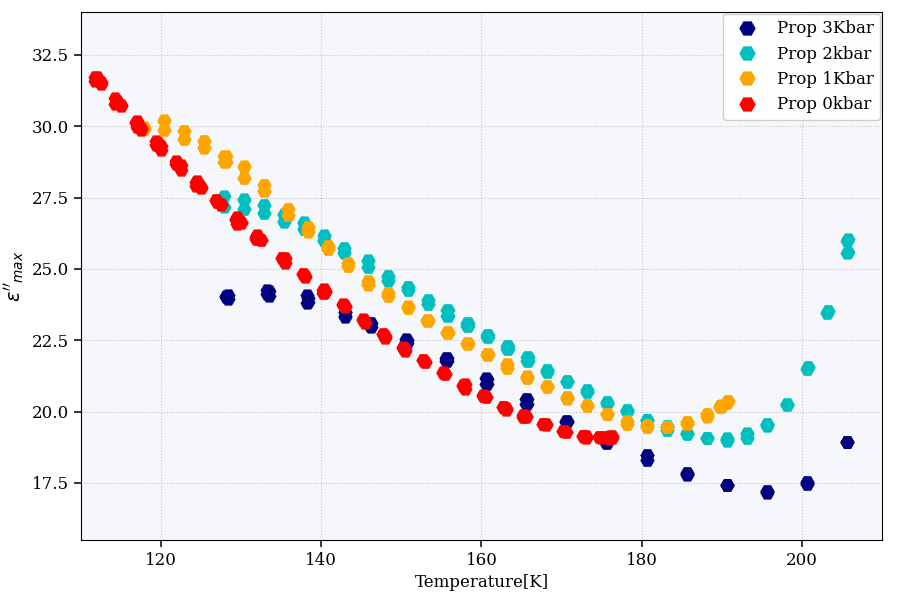

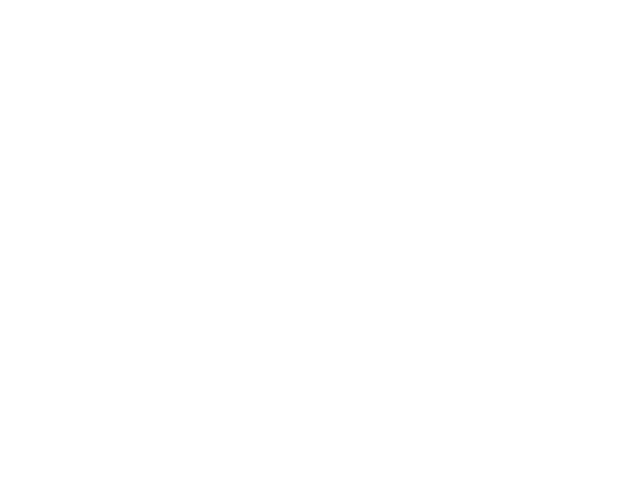

In [4]:
plt.clf()
#@ pressure dependent intensity of dilectric loss plot for propanol
skip3=[20445,20446,20447,20448]
skip1=[20175,20176,20177,20178,20179,20175,20181]
skip2=[20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]
# MixH = [f"windeta-{i}.diel" for i in range(first1, last1+1,2)if i not in skip]


# G9P_0Kbar = [load_diel(path, i) for i in range(21616, 21662)]
# G9P_1Kbar = [load_diel(path, i) for i in range(21541, 21593)]
# G9P_2Kbar = [load_diel(path, i) for i in range(21680, 21735)]
# G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]



prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20401)]
prop_2Kbar = [load_diel(path, i) for i in range(20211, 20274)]
prop_1Kbar = [load_diel(path, i) for i in range(20120, 20191)if i not in skip1]
prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457)if i not in skip3]
prop_0Kbar = [load_diel(path, i) for i in range(19992, 20072)if i not in skip2]
G9P_0Kbar = [load_diel(path, i) for i in range(21018, 21080)]
G9P_1Kbar = [load_diel(path, i) for i in range(21264, 21302)]
G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.1, top=0.98)
for dataset, label, marker, color in [(prop_3Kbar, '3Kbar', 'H', 'navy'),(prop_2Kbar, '2Kbar', 'H', 'c'), (prop_1Kbar, '1Kbar', 'H', 'orange'), (prop_0Kbar, '0Kbar', 'H', 'red')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        permitt2, intensity_at_idx0, frequency_at_idx0 = permittivity_at_fmax(df, permittivity, frequency)
        #permitt2=permittivity_at_fmax(df, permittivity, frequency)
        plt.plot(T, intensity_at_idx0, marker=marker, linestyle='--', markersize=9, color=color, label=label)
        plt.plot(T, permitt2, marker=marker, linestyle='--', markersize=9, color=color, label=label)
        ax.set_facecolor('#F5F7FA')
        
        
        

# plt.yscale('log')
plt.xlim(110, 210)  
plt.ylim(15.5, 34)  
ax.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('Temperature[K]', fontsize=12.0)
plt.ylabel('$ ε\'\'_{max}$',fontsize=14.0)
plt.xticks(fontsize='12')#fontweight='bold'
plt.yticks(fontsize='12')
# plt.legend()
# plt.grid(True, linestyle='--', linewidth=0.6, color='gray', alpha=0.9)
# ax.set_facecolor('#fafafa')
# plt.grid(True, linestyle='--', linewidth=0.6, color='gray', alpha=0.9)
plt.tick_params(axis='both', which='major', size=5, width=1.1, direction='out')

legend_elements = [
    
    Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='Prop 3Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='c', markersize=13, label='Prop 2kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='orange', markersize=13, label='Prop 1Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='red', markersize=13, label='Prop 0kbar'),
    # Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='1G9P 3Kbar')
    #Line2D([0], [0], marker='X', color='w', markerfacecolor='brown', markersize=13, label='1G9P_old_0Kb')
    
    
    
]

plt.legend(handles=legend_elements,loc='upper right', borderaxespad=0.1, ncol=1, fontsize='12', framealpha=0.9)
# plt.title('Maximum loss plot for 1-propanol with pressure and temperature', fontsize='16')
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/epsi_pressure.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/chapter_mixture/epsi_pressure.png',dpi=300)
plt.show()


[1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]
[1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]


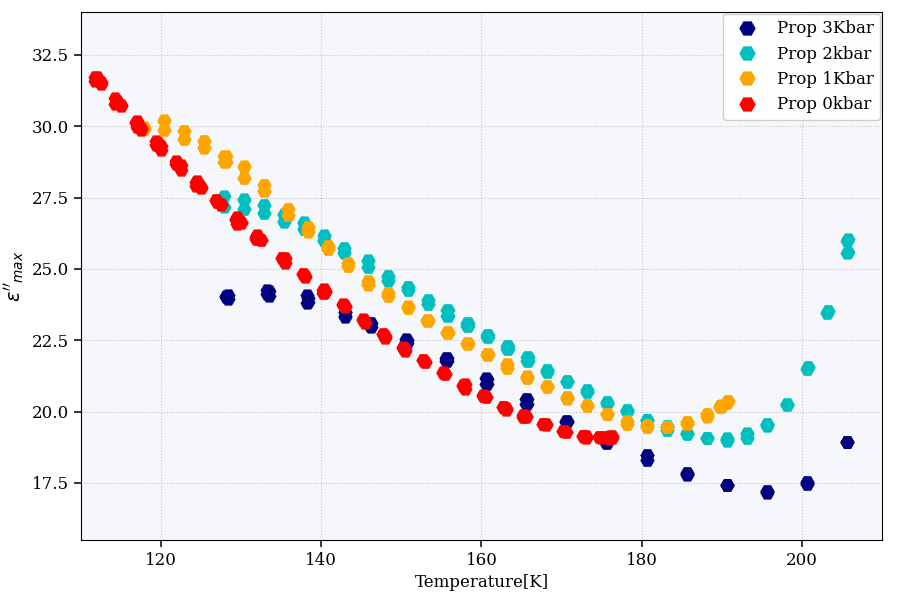

In [5]:
import numpy as np
import matplotlib.pyplot as plt
x=np.logspace(1,10,10)
print(x)
# x=np.log(x)
print(x)
y=0.4*np.exp(-x**0.1)+0.6*np.exp(-x**0.5)
y1=np.exp(-x)
# y1=np.log(y)
# plt.plot(x,np.log(y),'o-')
# plt.plot(x,np.log(y1),'s-')
plt.plot(x,(y),'o-')
plt.plot(x,(y1),'s-')

# plt.plot(np.log(x),(y),'o-')
# plt.plot(np.log(x),(y1),'s-')

plt.show()



Q= [0.32762343 0.30611111 0.26105383 0.22370598 0.20147579 0.18145466
 0.17355198 0.16841493 0.15596136 0.14437459 0.1290198  0.11789387
 0.11855315 0.10590488 0.09627015 0.08510913 0.07161856]
[19.17807056 20.52583222 24.06854259 28.08680131 31.18580855 34.62675063
 36.2034784  37.30776845 40.28680692 43.52002073 48.69938938 53.29526869
 52.99889095 59.32856937 65.26618362 73.82504449 87.73124691]
[360.2382091  343.12049784 317.93828974 293.79029209 281.56916763
 270.32418972 257.47403083 240.87247363 231.10772519 224.40400462
 209.23301831 199.59442811 194.92616548 184.94169677 179.72451087
 175.64326928 167.23577559]


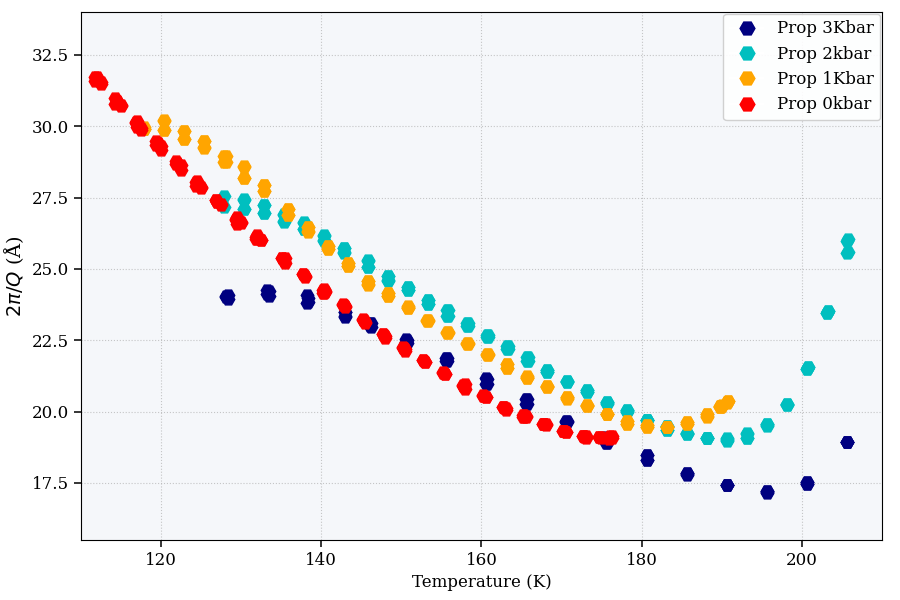

[0.07161856 0.08510913 0.09627015 0.10590488 0.11789387 0.11855315
 0.1290198  0.14437459 0.15596136 0.16841493 0.17355198 0.18145466
 0.20147579 0.22370598 0.26105383 0.30611111 0.32762343]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Data
log10_tau_s = np.array([
    -10.32, -10.14, -9.80, -9.44, -9.22, -9.00, -8.80, -8.54,
    -8.32, -8.14, -7.76, -7.48, -7.38, -7.04, -6.82, -6.60,
    -6.20
])

invT = np.array([
    2.77594096, 2.91442804, 3.14526445, 3.40378844, 3.55152522,
    3.69926199, 3.88388684, 4.15157442, 4.32698647, 4.45624846,
    4.77936039, 5.01015990, 5.13014760, 5.40710947, 5.56407134,
    5.69335793, 5.97958180
])

# Constants
D0 = 51.86       # Å^2 / ps
Ea = 2011.97     # K

# Conversions
T = 1000.0 / invT
tau_ps = 10**log10_tau_s * 1e12

# Correct Q(T)
Q = np.sqrt(np.exp(Ea / T) / (D0 * tau_ps))
print("Q=",Q)
print(2*np.pi/Q)
print(T)
# Length scale
length = 2 * np.pi / Q

# Plot
plt.plot(T, length, 'o-')
plt.xlabel("Temperature (K)")
plt.ylabel(r"$2\pi/Q$ (Å)")
plt.grid(True)
plt.show()
q1=np.array(np.sort(Q))
print(q1)

In [7]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize

# ======================================================
# GLOBAL 
# ======================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 7))

# ======================================================
# EXPERIMENTAL DIELECTRIC DATA (example: 0 kbar)
# ======================================================
for df in prop_0Kbar:
    eps2 = df["Eps''"].values
    freq = 2 * np.pi * df.index.values
    T = df['T'].iloc[0]

    tau = get_tau_max(df, eps2, freq)

    ax.plot(
        1000 / T,
        np.log10(tau),
        marker='H',
        linestyle='--',
        color='crimson',
        markersize=3,
        alpha=0.9,
        zorder=3
    )

# ======================================================
# HANSEN LITERATURE DATA 
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=30,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )



# ------------------------------------------------------
# dielectric data
# ------------------------------------------------------
skip3=[20445,20446,20447,20448]
skip1=[20175,20176,20177,20178,20179,20175,20181]
skip2=[20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20401)]
prop_2Kbar = [load_diel(path, i) for i in range(20211, 20274)]
prop_1Kbar = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_0Kbar = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
G9P_0Kbar = [load_diel(path, i) for i in range(21018, 21080)]
G9P_1Kbar = [load_diel(path, i) for i in range(21264, 21302)]
G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]

fig, ax = plt.subplots(figsize=(12, 7))

for dataset, label, marker, color in [
    # (prop_3Kbar, '3Kbar', 'H', 'navy'),
    # (prop_2Kbar, '2Kbar', 'H', 'c'),
    # (prop_1Kbar, '1Kbar', 'H', 'orange'),
    (prop_0Kbar, '0Kbar', 'H', 'red')
]:
    for df in dataset:
        permittivity = df["Eps''"].values
        frequency1 = df.index.values
        frequency = 2*np.pi*frequency1
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        ax.plot(1000/T, np.log10(tau1), marker=marker, linestyle='--',
                markersize=4, color=color, alpha=0.8)

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 

x_lit = data[:, 0]
y_lit = data[:, 1]

# ax.scatter(x_lit, y_lit, s=40, facecolors='none', edgecolors='black',
#            linewidths=1.1, label='Hansen et al.')




# Data from sillrene 8(b) saved in /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/deuteration_series/Data_extraction_Hansen/ 
# website  https://automeris.io/wpd/

datan= np.array([[3.00874279585077, -10.937655860349128],
[3.3880829935980605, -10.507481296758105],
[3.6192004209494297, -10.3142144638404],
[3.7131135191777096, -10.220698254364091],
[3.8142942913230904, -10.089775561097259],
[4.030975311945565, -9.902743142144638],
[4.229586088880594, -9.74064837905237],
[4.366934332338675, -9.541147132169577],
[4.4101715953578635, -9.572319201995013],
[4.558331403232226, -9.379052369077307],
[4.951973088019357, -9.036159600997507],
[5.136291372560483, -8.780548628428928],
[5.30249444018448, -8.581047381546135],
[5.504784027307745, -8.369077306733168],
[5.685513448120007, -8.100997506234414],
[5.765053102140951, -7.970074812967582],
[5.884331101911588, -7.795511221945137],
[5.996422379578556, -7.602244389027431],
[6.1084237107861545, -7.471321695760599],
[6.274626778410152, -7.271820448877806],
[6.393913772826726, -7.0910224438902745],
[6.498845312327838, -6.860349127182046],
[6.578393960994719, -6.723192019950125],
[6.650710914328246, -6.598503740648379],
[6.751990627578934, -6.399002493765586],
[6.809790222370135, -6.3366583541147135],
[6.900249376558604, -6.13715710723192],
[7.037660582538245, -5.894014962593516],
[7.185892347580104, -5.650872817955112],
[7.297911668079577, -5.507481296758105],
[7.355855177205769, -5.3453865336658355]])

                 




x_lit2 = datan[:, 0]
y_lit2 = datan[:, 1]

ax.scatter(x_lit2, y_lit2, s=40, facecolors='gray', edgecolors='blue',
           linewidths=1.1, label='Hansen et al.')




datapeak=np.array([[3.1882399501696614, -11.523690773067333],
[3.5422062517286586, -11.180798004987533],
[3.9466055330564487, -10.881546134663342],
[4.495602742467546, -10.35785536159601],
[5.535977459417282, -9.248129675810475],
[6.226154631455627, -8.369077306733168]])

x_lit5 = datapeak[:, 0]
y_lit5 = datapeak[:, 1]

# ax.scatter(x_lit5, y_lit5, s=40, facecolors='blue', edgecolors='blue',
#            linewidths=1.1, label='Hansen 8(b)')


datapre=np.array([[3.1966229601829514, -10.713216957605987],
[3.543501480743587, -10.283042394014963],
[3.955150446696604, -9.958852867830425],
[4.489774211900366, -9.397755610972569]])

x_lit6 = datapre[:, 0]
y_lit6 = datapre[:, 1]
# ax.scatter(x_lit6, y_lit6, s=40, facecolors='orange', edgecolors='red',
#            linewidths=1.1, label='Hansen 8(b)')








# Maxwell time for alpha relaxation extracted from sillren 8(b) using https://automeris.io/wpd/

maxd=np.array([[2.992818671454219, -11.79223046312035],
[3.1220825852782763, -11.598824998597305],
[3.2369838420107717, -11.477544889906966],
[3.359066427289048, -11.34045162393925],
3.473967684021544, -11.188083411290306],
[3.581687612208259, -11.054387762493414],
[3.718132854578097, -10.905951617992907],
[3.8258527827648114, -10.759392141398441],
[3.940754039497307, -10.630848056332388],
[4.077199281867145, -10.45651883806612],
[4.1849192100538595, -10.347154947991788],
[4.292639138240574, -10.22350824791644],
[4.40754039497307, -10.07095064189333],
[4.5368043087971275, -9.965700309796791],
[4.687612208258528, -9.817122648738236],
[4.8886894075403955, -9.598308246457577],
[5.017953321364453, -9.455131212592065],
[5.125673249551166, -9.35624075520505],
[5.254937163375224, -9.2166746186459],
[5.36983842010772, -9.106561613130763],
[5.470377019748653, -8.930136689349142],
[5.6068222621184916, -8.863521375038488],
[5.728904847396769, -8.757651251685953],
[5.836624775583482, -8.626944156968854],
[5.958707360861759, -8.40901006227154],
[6.066427289048473, -8.23369725835405],
[6.145421903052064, -8.110722302656377],
[6.296229802513465, -7.941757253561312],
[6.425493716337522, -7.741153324091542],
[6.518850987432674, -7.602615020389683],
[6.6122082585278275, -7.421659264057329],
[6.71274685816876, -7.255962488768091],
[6.834829443447037, -7.062006041822556],
[6.978456014362656, -6.862934249699012],
[7.064631956912028, -6.740094606740138],
[7.129263913824057, -6.579597125637926],
[7.193895870736085, -6.4326132555206215],
[7.244165170556553, -6.355607008452435],
[7.287253141831238, -6.2511650426341445],
[7.351885098743267, -6.14848930790198],
[7.4021543985637335, -6.065731560248864],
[7.4667863554757625, -5.957112668276477],
[3.1867145421903054, -11.739867954305831],
[3.5314183123877916, -11.256008655548044],
[3.9479353680430878, -10.874055072271412],
[4.493716337522441, -10.19349726273037],
[5.52064631956912, -8.916850934767885],
[6.217235188509874, -8.013692117140126]])


x_lit8 = maxd[:, 0]
y_lit8 = maxd[:, 1]
ax.scatter(x_lit8, y_lit8, s=40, facecolors='orange', edgecolors='red',
           linewidths=1.1, label='maxwell 8(b)')


# ------------------------------------------------------
# Computed Arrhenius curves for 15 q values
# ------------------------------------------------------

# q  
q_vals = np.array([
    0.43540808, 0.9486249, 1.84264577
])

gamma_0_methyl = [7.380490922810943, 7.380490922810943, 7.380490922810943
]

gamma_0_alpha = [20.639473063133295, 85.0370456856586, 231.11498782906622
]

gamma_0_debye = [7.850564134353516, 38.269807145436324, 193.70727679173183
]



Ea_methyl = 997.019973491501
Ea_alpha  = 1728.9273364788814
Ea_debye  = 2011.967929355119

Ea = [Ea_methyl, Ea_alpha, Ea_debye]

# Temperature range
k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 1000)



# Hansen main
plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 3)

# Hansen digitized variants
plot_lit(x_lit2, y_lit2, "Hansen 8(a)", "lightgray", "navy", "s", 3)
plot_lit(x_lit5, y_lit5, "Hansen 8(b) peak", "royalblue", "royalblue", "D", 3)
plot_lit(x_lit6, y_lit6, "Hansen 8(b) pre", "orange", "darkred", "^", 3)

# ======================================================
# COMPUTED ARRHENIUS CURVES
# ======================================================
k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / (k_B * T))
    return (hbar_meV_ps / gamma) * ps_to_s

# q setup
norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("pink")
cmap_debye  = get_cmap("spring")
cmap_methyl = get_cmap("Greys")

# methyl
for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(
        1000 / T,
        np.log10(Tau(Ea_methyl, g0, T)),
        color=cmap_methyl(norm(q)),
        lw=1.8,
        alpha=0.9,
        zorder=1)

# alpha
for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(
        1000 / T,
        np.log10(Tau(Ea_alpha, g0, T)),
        color=cmap_alpha(norm(q)),
        
        lw=3.8,
        alpha=0.9,
        zorder=1)

# debye
for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(
        1000 / T,
        np.log10(Tau(Ea_debye, g0, T)),
        color=cmap_debye(norm(q)),
        lw=1.8,
        alpha=0.9,
        zorder=1)

# ======================================================
# IN16B TIME WINDOW
# ======================================================
tau_min = 6.582e-16 / (30e-6)
tau_max = 6.582e-16 / (0.75e-6)

ax.fill_between([1, 13],np.log10(tau_min),np.log10(tau_max),color="gray",alpha=0.25,zorder=0,label="IN16B window")

ax.axhline(np.log10(tau_min), ls="--", lw=1, color="black")
ax.axhline(np.log10(tau_max), ls="--", lw=1, color="black")

# ======================================================
# HBOND LIFETIME DATA
# ======================================================
# taus_s= [4.88511177e-10, 4.67665180e-10, 2.77443763e-10, 7.33720258e-11,
#  7.54087007e-11, 4.32993174e-11,  1.06620127e-11,  #1.43567174e-11,
#  7.49018138e-12, 4.20090545e-12]
# x_hb= [8.33333333 ,6.66666667, 5.55555556, 4.54545455, 4.     ,    3.7037037, #3.33333333
#   3.03030303, 2.85714286, 2.56410256]




taus_s= [ 7.54087007e-11, 4.32993174e-11,  1.06620127e-11,  7.49018138e-12, 4.20090545e-12] #1.43567174e-11,
x_hb= [ 4.     ,    3.7037037,3.03030303, 2.85714286, 2.56410256]  #3.33333333



ax.scatter(x_hb,np.log10(taus_s),s=65,facecolors="forestgreen", edgecolors="forestgreen",label="H-bond lifetime",zorder=6)

# ax.scatter(
#     temp_fit,
#     np.log10(Tau_fitexp),
#     s=65,
#     facecolors="black",
#     edgecolors="black",
#     label="H-bond (fit)",
#     zorder=6
# )

# ======================================================
# COLORBARS
# ======================================================
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap_alpha), ax=ax,pad=0.01,label="q (α)")

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap_debye),ax=ax,pad=0.10,label="q (Debye)")

# ======================================================
# AXES & GRID
# ======================================================
ax.set_xlim(2, 8)
ax.set_ylim(-13, -6)

ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$")
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$")

ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.8)
ax.grid(True, which="minor", ls=":", lw=0.4, alpha=0.5)
ax.minorticks_on()

# ======================================================
# LEGEND (DATA ONLY)
# ======================================================
legend_elements = [Line2D([0], [0], marker='H', color='crimson', lw=0, markersize=10, label='PropOH 0 kbar'),
                   Line2D([0], [0], marker='o', color='black', markerfacecolor='none', lw=0, markersize=9, label='Hansen et al.'),
                   Line2D([0], [0], marker='s', color='navy', markerfacecolor='lightgray', lw=0, markersize=9, label='Hansen (digitized)'),
                   Line2D([0], [0], marker='D', color='royalblue', lw=0, markersize=9, label='Hansen 8(b) peak'),
                   Line2D([0], [0], marker='^', color='darkred', markerfacecolor='orange', lw=0, markersize=9, label='Hansen 8(b) pre'),]

ax.legend(handles=legend_elements, loc="upper left", framealpha=0.95)

plt.tight_layout()
plt.show()


SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' on line 244 (3930629118.py, line 291)

In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series 
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.figsize": (9, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.10, top=0.97, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]

# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
for df in prop_0Kbar:
    eps2 = df["Eps''"].values
    freq = 2 * np.pi * df.index.values
    Tval = df['T'].iloc[0]
    tau = get_tau_max(df, eps2, freq)

    ax.plot(
        1000 / Tval,
        np.log10(tau),
        marker='H',
        linestyle='--',
        color='crimson',
        markersize=4,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  
x_lit, y_lit = data[:,0], data[:,1]

plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 3)

# ======================================================
# DIGITIZED HANSEN FIG. 8(a)
# ======================================================
# Data from sillrene 8(b) saved in /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/deuteration_series/Data_extraction_Hansen/ 
# website  https://automeris.io/wpd/

datan= np.array([[3.00874279585077, -10.937655860349128],
[3.3880829935980605, -10.507481296758105],
[3.6192004209494297, -10.3142144638404],
[3.7131135191777096, -10.220698254364091],
[3.8142942913230904, -10.089775561097259],
[4.030975311945565, -9.902743142144638],
[4.229586088880594, -9.74064837905237],
[4.366934332338675, -9.541147132169577],
[4.4101715953578635, -9.572319201995013],
[4.558331403232226, -9.379052369077307],
[4.951973088019357, -9.036159600997507],
[5.136291372560483, -8.780548628428928],
[5.30249444018448, -8.581047381546135],
[5.504784027307745, -8.369077306733168],
[5.685513448120007, -8.100997506234414],
[5.765053102140951, -7.970074812967582],
[5.884331101911588, -7.795511221945137],
[5.996422379578556, -7.602244389027431],
[6.1084237107861545, -7.471321695760599],
[6.274626778410152, -7.271820448877806],
[6.393913772826726, -7.0910224438902745],
[6.498845312327838, -6.860349127182046],
[6.578393960994719, -6.723192019950125],
[6.650710914328246, -6.598503740648379],
[6.751990627578934, -6.399002493765586],
[6.809790222370135, -6.3366583541147135],
[6.900249376558604, -6.13715710723192],
[7.037660582538245, -5.894014962593516],
[7.185892347580104, -5.650872817955112],
[7.297911668079577, -5.507481296758105],
[7.355855177205769, -5.3453865336658355]])

                 



# datan = np.array([...])  
x_lit2, y_lit2 = datan[:,0], datan[:,1]
plot_lit(x_lit2, y_lit2, "Poschl et al.", "lightgray", "navy", "s", 3)

# ======================================================
# HANSEN FIG. 8(b): PEAK & PRE-PEAK
# ======================================================


datapeak=np.array([[3.1882399501696614, -11.523690773067333],
[3.5422062517286586, -11.180798004987533],
[3.9466055330564487, -10.881546134663342],
[4.495602742467546, -10.35785536159601],
[5.535977459417282, -9.248129675810475],
[6.226154631455627, -8.369077306733168]])

datapre=np.array([[3.1966229601829514, -10.713216957605987],
[3.543501480743587, -10.283042394014963],
[3.955150446696604, -9.958852867830425],
[4.489774211900366, -9.397755610972569]])


plot_lit(datapeak[:,0], datapeak[:,1], "Sillren et al. peak",
         "royalblue", "royalblue", "D", 4)

plot_lit(datapre[:,0], datapre[:,1], "Sillren et al. prepeak",
         "orange", "darkred", "^", 4)

# ======================================================
# MAXWELL TIME (α) – DIGITIZED FROM 8(b)
# ======================================================
maxd = np.array([
    [2.992818671454219, -11.79223046312035],
    [3.1220825852782763, -11.598824998597305],
    [3.2369838420107717, -11.477544889906966],
    [3.359066427289048, -11.34045162393925],
    [3.473967684021544, -11.188083411290306],
    [3.581687612208259, -11.054387762493414],
    [3.718132854578097, -10.905951617992907],
    [3.8258527827648114, -10.759392141398441],
    [3.940754039497307, -10.630848056332388],
    [4.077199281867145, -10.45651883806612],
    [4.1849192100538595, -10.347154947991788],
    [4.292639138240574, -10.22350824791644],
    [4.40754039497307, -10.07095064189333],
    [4.5368043087971275, -9.965700309796791],
    [4.687612208258528, -9.817122648738236],
    [4.8886894075403955, -9.598308246457577],
    [5.017953321364453, -9.455131212592065],
    [5.125673249551166, -9.35624075520505],
    [5.254937163375224, -9.2166746186459],
    [5.36983842010772, -9.106561613130763],
    [5.470377019748653, -8.930136689349142],
    [5.6068222621184916, -8.863521375038488],
    [5.728904847396769, -8.757651251685953],
    [5.836624775583482, -8.626944156968854],
    [5.958707360861759, -8.40901006227154],
    [6.066427289048473, -8.23369725835405],
    [6.145421903052064, -8.110722302656377],
    [6.296229802513465, -7.941757253561312],
    [6.425493716337522, -7.741153324091542],
    [6.518850987432674, -7.602615020389683],
    [6.6122082585278275, -7.421659264057329],
    [6.71274685816876, -7.255962488768091],
    [6.834829443447037, -7.062006041822556],
    [6.978456014362656, -6.862934249699012],
    [7.064631956912028, -6.740094606740138],
    [7.129263913824057, -6.579597125637926],
    [7.193895870736085, -6.4326132555206215],
    [7.244165170556553, -6.355607008452435],
    [7.287253141831238, -6.2511650426341445],
    [7.351885098743267, -6.14848930790198],
    [7.4021543985637335, -6.065731560248864],
    [7.4667863554757625, -5.957112668276477],
])

ax.scatter(
    maxd[:,0], maxd[:,1],
    s=40, facecolors='orange', edgecolors='red',
    linewidths=1.1, label='Maxwell time (α)', zorder=5
)

# ======================================================
# COMPUTED ARRHENIUS CURVES
# ======================================================


# # q  for 4 q values
# q_vals = np.array([0.43540808, 0.70713226, 1.47556498, 1.84264577])

# gamma_0_methyl = [7.380490922810943,  7.380490922810943, 7.380490922810943, 7.380490922810943
# ]

# gamma_0_alpha = [ 20.639473063133295,  46.359245701833345, 158.86500146216426,231.11498782906622
# ]

# gamma_0_debye = [7.850564134353516,  19.561620037081457, 110.69349194018784, 193.70727679173183 ]



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '--',
            color=cmap_alpha(norm(q)), lw=3.8, zorder=1,label=rf"Intermediate $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"Slowest $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"

# ======================================================
# H-BOND LIFETIME
# ======================================================
taus_s = [7.54e-11, 4.33e-11, 1.07e-11, 7.49e-12, 4.20e-12]
x_hb   = [4.0, 3.7037, 3.0303, 2.8571, 2.5641]

ax.scatter(
    x_hb, np.log10(taus_s),
    s=65, facecolors="forestgreen", edgecolors="forestgreen",
    label="H-bond lifetime(MD)", zorder=6
)




x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  # stagger arrows to avoid overlap
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=10, fontweight='bold', color='tab:green'
)





# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$")
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$")

ax.grid(True, which="major", ls="--", lw=0.5)
ax.grid(True, which="minor", ls=":", lw=0.4)
ax.minorticks_on()

ax.legend(loc="upper left", framealpha=0.95,ncol=1)
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/Arrhenius_plot_all_MD_hbond3.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series – for  model 3L four gamma0(Gamma0A and Gamma0B)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.10, top=0.97, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]

# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
for df in prop_0Kbar:
    eps2 = df["Eps''"].values
    freq = 2 * np.pi * df.index.values
    Tval = df['T'].iloc[0]
    tau = get_tau_max(df, eps2, freq)

    ax.plot(
        1000 / Tval,
        np.log10(tau),
        marker='H',
        linestyle='--',
        color='crimson',
        markersize=4,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  #  full array
x_lit, y_lit = data[:,0], data[:,1]

# plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 3)

# ======================================================
# DIGITIZED HANSEN FIG. 8(a)
# ======================================================
# Data from sillrene 8(b) saved in /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/deuteration_series/Data_extraction_Hansen/ 
# website  https://automeris.io/wpd/

datan= np.array([[3.00874279585077, -10.937655860349128],
[3.3880829935980605, -10.507481296758105],
[3.6192004209494297, -10.3142144638404],
[3.7131135191777096, -10.220698254364091],
[3.8142942913230904, -10.089775561097259],
[4.030975311945565, -9.902743142144638],
[4.229586088880594, -9.74064837905237],
[4.366934332338675, -9.541147132169577],
[4.4101715953578635, -9.572319201995013],
[4.558331403232226, -9.379052369077307],
[4.951973088019357, -9.036159600997507],
[5.136291372560483, -8.780548628428928],
[5.30249444018448, -8.581047381546135],
[5.504784027307745, -8.369077306733168],
[5.685513448120007, -8.100997506234414],
[5.765053102140951, -7.970074812967582],
[5.884331101911588, -7.795511221945137],
[5.996422379578556, -7.602244389027431],
[6.1084237107861545, -7.471321695760599],
[6.274626778410152, -7.271820448877806],
[6.393913772826726, -7.0910224438902745],
[6.498845312327838, -6.860349127182046],
[6.578393960994719, -6.723192019950125],
[6.650710914328246, -6.598503740648379],
[6.751990627578934, -6.399002493765586],
[6.809790222370135, -6.3366583541147135],
[6.900249376558604, -6.13715710723192],
[7.037660582538245, -5.894014962593516],
[7.185892347580104, -5.650872817955112],
[7.297911668079577, -5.507481296758105],
[7.355855177205769, -5.3453865336658355]])

                 



# datan = np.array([...])  # unchanged
x_lit2, y_lit2 = datan[:,0], datan[:,1]
# plot_lit(x_lit2, y_lit2, "Poschl et al.", "lightgray", "navy", "s", 3)

# ======================================================
# HANSEN FIG. 8(b): PEAK & PRE-PEAK
# ======================================================


datapeak=np.array([[3.1882399501696614, -11.523690773067333],
[3.5422062517286586, -11.180798004987533],
[3.9466055330564487, -10.881546134663342],
[4.495602742467546, -10.35785536159601],
[5.535977459417282, -9.248129675810475],
[6.226154631455627, -8.369077306733168]])

datapre=np.array([[3.1966229601829514, -10.713216957605987],
[3.543501480743587, -10.283042394014963],
[3.955150446696604, -9.958852867830425],
[4.489774211900366, -9.397755610972569]])


# plot_lit(datapeak[:,0], datapeak[:,1], "Sillren et al. peak",
#          "royalblue", "royalblue", "D", 4)

# plot_lit(datapre[:,0], datapre[:,1], "Sillren et al. prepeak",
#          "orange", "darkred", "^", 4)

# ======================================================
# MAXWELL TIME (α) – DIGITIZED FROM 8(b)
# ======================================================
maxd = np.array([
    [2.992818671454219, -11.79223046312035],
    [3.1220825852782763, -11.598824998597305],
    [3.2369838420107717, -11.477544889906966],
    [3.359066427289048, -11.34045162393925],
    [3.473967684021544, -11.188083411290306],
    [3.581687612208259, -11.054387762493414],
    [3.718132854578097, -10.905951617992907],
    [3.8258527827648114, -10.759392141398441],
    [3.940754039497307, -10.630848056332388],
    [4.077199281867145, -10.45651883806612],
    [4.1849192100538595, -10.347154947991788],
    [4.292639138240574, -10.22350824791644],
    [4.40754039497307, -10.07095064189333],
    [4.5368043087971275, -9.965700309796791],
    [4.687612208258528, -9.817122648738236],
    [4.8886894075403955, -9.598308246457577],
    [5.017953321364453, -9.455131212592065],
    [5.125673249551166, -9.35624075520505],
    [5.254937163375224, -9.2166746186459],
    [5.36983842010772, -9.106561613130763],
    [5.470377019748653, -8.930136689349142],
    [5.6068222621184916, -8.863521375038488],
    [5.728904847396769, -8.757651251685953],
    [5.836624775583482, -8.626944156968854],
    [5.958707360861759, -8.40901006227154],
    [6.066427289048473, -8.23369725835405],
    [6.145421903052064, -8.110722302656377],
    [6.296229802513465, -7.941757253561312],
    [6.425493716337522, -7.741153324091542],
    [6.518850987432674, -7.602615020389683],
    [6.6122082585278275, -7.421659264057329],
    [6.71274685816876, -7.255962488768091],
    [6.834829443447037, -7.062006041822556],
    [6.978456014362656, -6.862934249699012],
    [7.064631956912028, -6.740094606740138],
    [7.129263913824057, -6.579597125637926],
    [7.193895870736085, -6.4326132555206215],
    [7.244165170556553, -6.355607008452435],
    [7.287253141831238, -6.2511650426341445],
    [7.351885098743267, -6.14848930790198],
    [7.4021543985637335, -6.065731560248864],
    [7.4667863554757625, -5.957112668276477],
])

# ax.scatter(
#     maxd[:,0], maxd[:,1],
#     s=40, facecolors='orange', edgecolors='red',
#     linewidths=1.1, label='Maxwell time (α)', zorder=5
# )

# ======================================================
# COMPUTED ARRHENIUS CURVES
# ======================================================


# # q  for 4 q values
# q_vals = np.array([0.43540808, 0.70713226, 1.47556498, 1.84264577])

# gamma_0_methyl = [7.380490922810943,  7.380490922810943, 7.380490922810943, 7.380490922810943
# ]

# gamma_0_alpha = [ 20.639473063133295,  46.359245701833345, 158.86500146216426,231.11498782906622
# ]

# gamma_0_debye = [7.850564134353516,  19.561620037081457, 110.69349194018784, 193.70727679173183 ]



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),"--",
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '--',
            color=cmap_alpha(norm(q)), lw=3.8, zorder=1,label=rf"Intermediate $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),"--",
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"Slowest $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"

# ======================================================
# H-BOND LIFETIME
# ======================================================
taus_s = [7.54e-11, 4.33e-11, 1.07e-11, 7.49e-12, 4.20e-12]
x_hb   = [4.0, 3.7037, 3.0303, 2.8571, 2.5641]

ax.scatter(
    x_hb, np.log10(taus_s),
    s=65, facecolors="forestgreen", edgecolors="forestgreen",
    label="H-bond lifetime(MD)", zorder=6
)




x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  # stagger arrows to avoid overlap
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=10, fontweight='bold', color='tab:green'
)


#################$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$new model ########################################################################


# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl2 = [4.198823989434325,  4.198823989434325]

gamma_0_alphaA = [ 8.911243516892881, 26.595038962892545]
gamma_0_alphaB = [ 13.547857730972465, 80.55379242498677]

gamma_0_debye2 = [ 13.547857730972465, 80.553792424986773]



Ea_methyl2, Ea_alphaA, Ea_alphaB, Ea_debye2 = 874.3647397121288, 1424.0792719978176, 1909.420459609302, 1909.420459609302

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alphaA  = get_cmap("brg")
cmap_alphaB  = get_cmap("BrBG")
cmap_debye2  = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl2, g0, T)), '-',
            color=cmap_methyl2(norm(q)), lw=1.8, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T)), '-',
            color=cmap_alphaA(norm(q)), lw=3.8, zorder=1,label=rf"IntermediateA $q = {q:.2f}Å⁻¹$")


# for q, g0 in zip(q_vals, gamma_0_alphaB):
#     ax.plot(1000/T, np.log10(Tau(Ea_alphaB, g0, T)), '-.',
#             color=cmap_alphaB(norm(q)), lw=3.8, zorder=1,label=rf"IntermediateB $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T))+np.log10(Tau(Ea_alphaB, g0, T)), 's',
            color=cmap_alphaA(norm(q)), lw=3.8, zorder=1,label=rf"sum $q = {q:.2f}Å⁻¹$")



for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000/T, np.log10(Tau(Ea_debye2, g0, T)), '-',
            color=cmap_debye2(norm(q)), lw=1.8, zorder=1, label=rf"Slowest_new $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"





# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$")
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$")

ax.grid(True, which="major", ls="--", lw=0.5)
ax.grid(True, which="minor", ls=":", lw=0.4)
ax.minorticks_on()

ax.legend(loc="upper left", framealpha=0.95,ncol=2)
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/deuteration_series/Arrhenius_plot_all_MD_hbond2_.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series -mixture
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.10, top=0.97, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]

# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
for df in prop_0Kbar:
    eps2 = df["Eps''"].values
    freq = 2 * np.pi * df.index.values
    Tval = df['T'].iloc[0]
    tau = get_tau_max(df, eps2, freq)

    ax.plot(
        1000 / Tval,
        np.log10(tau),
        marker='H',
        linestyle='--',
        color='crimson',
        markersize=4,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  #  full array
x_lit, y_lit = data[:,0], data[:,1]

plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 3)

# ======================================================
# DIGITIZED HANSEN FIG. 8(a)
# ======================================================
# Data from sillrene 8(b) saved in /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/deuteration_series/Data_extraction_Hansen/ 
# website  https://automeris.io/wpd/

datan= np.array([[3.00874279585077, -10.937655860349128],
[3.3880829935980605, -10.507481296758105],
[3.6192004209494297, -10.3142144638404],
[3.7131135191777096, -10.220698254364091],
[3.8142942913230904, -10.089775561097259],
[4.030975311945565, -9.902743142144638],
[4.229586088880594, -9.74064837905237],
[4.366934332338675, -9.541147132169577],
[4.4101715953578635, -9.572319201995013],
[4.558331403232226, -9.379052369077307],
[4.951973088019357, -9.036159600997507],
[5.136291372560483, -8.780548628428928],
[5.30249444018448, -8.581047381546135],
[5.504784027307745, -8.369077306733168],
[5.685513448120007, -8.100997506234414],
[5.765053102140951, -7.970074812967582],
[5.884331101911588, -7.795511221945137],
[5.996422379578556, -7.602244389027431],
[6.1084237107861545, -7.471321695760599],
[6.274626778410152, -7.271820448877806],
[6.393913772826726, -7.0910224438902745],
[6.498845312327838, -6.860349127182046],
[6.578393960994719, -6.723192019950125],
[6.650710914328246, -6.598503740648379],
[6.751990627578934, -6.399002493765586],
[6.809790222370135, -6.3366583541147135],
[6.900249376558604, -6.13715710723192],
[7.037660582538245, -5.894014962593516],
[7.185892347580104, -5.650872817955112],
[7.297911668079577, -5.507481296758105],
[7.355855177205769, -5.3453865336658355]])

                 



# datan = np.array([...])  # 
x_lit2, y_lit2 = datan[:,0], datan[:,1]
plot_lit(x_lit2, y_lit2, "Poschl et al.", "lightgray", "navy", "s", 3)

# ======================================================
# HANSEN FIG. 8(b): PEAK & PRE-PEAK
# ======================================================


datapeak=np.array([[3.1882399501696614, -11.523690773067333],
[3.5422062517286586, -11.180798004987533],
[3.9466055330564487, -10.881546134663342],
[4.495602742467546, -10.35785536159601],
[5.535977459417282, -9.248129675810475],
[6.226154631455627, -8.369077306733168]])

datapre=np.array([[3.1966229601829514, -10.713216957605987],
[3.543501480743587, -10.283042394014963],
[3.955150446696604, -9.958852867830425],
[4.489774211900366, -9.397755610972569]])


plot_lit(datapeak[:,0], datapeak[:,1], "Sillren et al. peak",
         "royalblue", "royalblue", "D", 4)

plot_lit(datapre[:,0], datapre[:,1], "Sillren et al. prepeak",
         "orange", "darkred", "^", 4)

# ======================================================
# MAXWELL TIME (α) : DIGITIZED FROM 8(b)
# ======================================================
maxd = np.array([
    [2.992818671454219, -11.79223046312035],
    [3.1220825852782763, -11.598824998597305],
    [3.2369838420107717, -11.477544889906966],
    [3.359066427289048, -11.34045162393925],
    [3.473967684021544, -11.188083411290306],
    [3.581687612208259, -11.054387762493414],
    [3.718132854578097, -10.905951617992907],
    [3.8258527827648114, -10.759392141398441],
    [3.940754039497307, -10.630848056332388],
    [4.077199281867145, -10.45651883806612],
    [4.1849192100538595, -10.347154947991788],
    [4.292639138240574, -10.22350824791644],
    [4.40754039497307, -10.07095064189333],
    [4.5368043087971275, -9.965700309796791],
    [4.687612208258528, -9.817122648738236],
    [4.8886894075403955, -9.598308246457577],
    [5.017953321364453, -9.455131212592065],
    [5.125673249551166, -9.35624075520505],
    [5.254937163375224, -9.2166746186459],
    [5.36983842010772, -9.106561613130763],
    [5.470377019748653, -8.930136689349142],
    [5.6068222621184916, -8.863521375038488],
    [5.728904847396769, -8.757651251685953],
    [5.836624775583482, -8.626944156968854],
    [5.958707360861759, -8.40901006227154],
    [6.066427289048473, -8.23369725835405],
    [6.145421903052064, -8.110722302656377],
    [6.296229802513465, -7.941757253561312],
    [6.425493716337522, -7.741153324091542],
    [6.518850987432674, -7.602615020389683],
    [6.6122082585278275, -7.421659264057329],
    [6.71274685816876, -7.255962488768091],
    [6.834829443447037, -7.062006041822556],
    [6.978456014362656, -6.862934249699012],
    [7.064631956912028, -6.740094606740138],
    [7.129263913824057, -6.579597125637926],
    [7.193895870736085, -6.4326132555206215],
    [7.244165170556553, -6.355607008452435],
    [7.287253141831238, -6.2511650426341445],
    [7.351885098743267, -6.14848930790198],
    [7.4021543985637335, -6.065731560248864],
    [7.4667863554757625, -5.957112668276477],
])

ax.scatter(
    maxd[:,0], maxd[:,1],
    s=40, facecolors='orange', edgecolors='red',
    linewidths=1.1, label='Maxwell time (α)', zorder=5
)

# ======================================================
# COMPUTED ARRHENIUS CURVES
# ======================================================


# # q  for 4 q values
# q_vals = np.array([0.43540808, 0.70713226, 1.47556498, 1.84264577])

# gamma_0_methyl = [7.380490922810943,  7.380490922810943, 7.380490922810943, 7.380490922810943
# ]

# gamma_0_alpha = [ 20.639473063133295,  46.359245701833345, 158.86500146216426,231.11498782906622
# ]

# gamma_0_debye = [7.850564134353516,  19.561620037081457, 110.69349194018784, 193.70727679173183 ]



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '--',
            color=cmap_alpha(norm(q)), lw=3.8, zorder=1,label=rf"Intermediate $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"Slowest $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"

# ======================================================
# H-BOND LIFETIME
# ======================================================
taus_s = [7.54e-11, 4.33e-11, 1.07e-11, 7.49e-12, 4.20e-12]
x_hb   = [4.0, 3.7037, 3.0303, 2.8571, 2.5641]

ax.scatter(
    x_hb, np.log10(taus_s),
    s=65, facecolors="forestgreen", edgecolors="forestgreen",
    label="H-bond lifetime(MD)", zorder=6
)




x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  # stagger arrows to avoid overlap
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=10, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=10, fontweight='bold', color='tab:green'
)



#################%%%%%%%%%%%%%%%%%%%%%%%%%%%mixture##############################


# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl2 = [4.230536089265434,  4.230536089265434]

gamma_0_alphaA = [ 18.66305733043451, 48.080899354346556]

gamma_0_debye2 = [30.430680711343673, 130.67227431554807]



Ea_methyl2, Ea_alphaA, Ea_debye2 = 986.6231209709857, 1677.3413437577879, 2312.8932387701784

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alphaA  = get_cmap("brg")
# cmap_alphaB  = get_cmap("BrBG")
cmap_debye2  = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color=cmap_methyl2(norm(q)), lw=1.8, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T)), '*',
            color=cmap_alphaA(norm(q)), lw=1.8, zorder=1,label=rf"Intermediate_mix $q = {q:.2f}Å⁻¹$")


for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000/T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color=cmap_debye2(norm(q)), lw=1.8, zorder=1, label=rf"Slowest_mix $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"






# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$")
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$")

ax.grid(True, which="major", ls="--", lw=0.5)
ax.grid(True, which="minor", ls=":", lw=0.4)
ax.minorticks_on()

ax.legend(loc="upper left", framealpha=0.95,ncol=2)
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Arrhenius_plot_mix.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D

# ============================================================
# PHYSICAL CONSTANTS
# ============================================================
k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12

def Gamma(Ea, gamma0, T):
    return gamma0 * np.exp(-Ea / (k_B * T))

def Tau(Ea, gamma0, T):
    return (hbar_meV_ps / Gamma(Ea, gamma0, T)) * ps_to_s  # seconds

# ============================================================
# GENERAL ISOCHRONE CALCULATION
# ============================================================
def compute_isochrone_temperatures(q_vals, gamma0_list, Ea_list, pressures, 
                                   T_range, target_log_tau):
    iso_T = {}
    for q_idx, q in enumerate(q_vals):
        gamma0 = gamma0_list[q_idx]
        iso_T[q] = {}

        for p_idx, P in enumerate(pressures):
            Ea = Ea_list[p_idx]
            tau = Tau(Ea, gamma0, T_range)
            log_tau = np.log10(tau)

            # Cannot find solution → return NaN
            if np.all(log_tau > target_log_tau) or np.all(log_tau < target_log_tau):
                iso_T[q][P] = np.nan
                continue

            # Interpolation
            f = interp1d(log_tau, T_range, fill_value="extrapolate")
            iso_T[q][P] = float(f(target_log_tau))
    return iso_T

# ============================================================
# INPUT DATA
# ============================================================

q_vals = np.array([0.43540808, 1.06619779, 1.84264577])

gamma_0_methyl = [7.380490922810943] * 3
gamma_0_alpha  = [20.639473063133295, 102.07683363847075, 231.11498782906622]
gamma_0_debye  = [7.850564134353516, 51.76111175930305, 193.70727679173183]

Ea_methyl = np.array([997.02, 1102.9666110092046, 1163.1287935811115,
                      1237.5061062476354, 1252.62196121046])

Ea_alpha = np.array([1728.93, 1924.76521281567, 2039.2651800396764,
                     2244.0019776070744, 2283.194211479879])

Ea_debye = np.array([2011.97, 2280.5620196904442, 2433.4996606953623,
                     2652.940943732253, 2712.6415741305937])

pressures = np.array([0, 1.5, 3, 5, 6])
T_range = np.linspace(80, 500, 2000)

target_log_tau = -10  # YOU CAN CHANGE THIS



# ============================================================
# COMPUTE ISOCHRONES
# ============================================================
iso_methyl = compute_isochrone_temperatures(q_vals, gamma_0_methyl, Ea_methyl,
                                            pressures, T_range, target_log_tau)

iso_alpha  = compute_isochrone_temperatures(q_vals, gamma_0_alpha, Ea_alpha,
                                            pressures, T_range, target_log_tau)

iso_debye  = compute_isochrone_temperatures(q_vals, gamma_0_debye, Ea_debye,
                                            pressures, T_range, target_log_tau)

# ============================================================
# SETUP PLOTTING COLORS & MARKERS
# ============================================================

# Methyl → Single black curve
color_methyl = "black"
marker_methyl = "o"

# Gradients for alpha & debye
cmap_alpha = get_cmap("plasma")
cmap_debye = get_cmap("copper")
q_norm = np.linspace(0, 1, len(q_vals))

colors_alpha = [cmap_alpha(qn) for qn in q_norm]
colors_debye = [cmap_debye(qn) for qn in q_norm]

marker_alpha = "s"
marker_debye = "D"

# ============================================================
# PLOTTING
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.06, right=0.98, bottom=0.1, top=0.98)
# --- METHYL SINGLE CURVE ---
temps_methyl = [iso_methyl[q_vals[0]][P] for P in pressures]
ax.plot(temps_methyl, pressures, "-", color=color_methyl, marker=marker_methyl,
        markersize=8, linewidth=2.5, label="I")

# Label ΔT on methyl
dT_methyl = iso_methyl[q_vals[0]][6] - iso_methyl[q_vals[0]][0]
ax.text(temps_methyl[-1], pressures[-1] + 0.15,
        f"ΔT={dT_methyl:.1f}K",
        color=color_methyl, fontsize=12)

# --- ALPHA & DEBYE MULTI-Q ---
for idx, q in enumerate(q_vals):

    # Alpha
    temps = [iso_alpha[q][P] for P in pressures]
    ax.plot(temps, pressures, "-", color=colors_alpha[idx], marker=marker_alpha,
            markersize=7, linewidth=2, label=f"II  q={q:.2f}")

    # ΔT label
    dT = temps[-1] - temps[0]
    ax.text(temps[-1], pressures[-1] + 0.15,
            f"{dT:.1f}K", color=colors_alpha[idx], fontsize=12)

    # Debye
    temps = [iso_debye[q][P] for P in pressures]
    ax.plot(temps, pressures, "--", color=colors_debye[idx], marker=marker_debye,
            markersize=7, linewidth=2, label=f"III q={q:.2f}")

    # ΔT label
    dT = temps[-1] - temps[0]
    ax.text(temps[-1], pressures[-1] + 0.15,
            f"{dT:.1f}K", color=colors_debye[idx], fontsize=12)

# ============================================================
# AXIS + 
# ============================================================
ax.set_xlabel("Temperature[K]", fontsize=12)
ax.set_ylabel("Pressure[kbar]", fontsize=12)
# ax.set_title(f"Isochrones for log₁₀(τ [s]) = {target_log_tau}",
#              fontsize=18, fontweight="bold")

ax.set_ylim(-0.5,6.5)
ax.set_xlim(120,410)
ax.set_facecolor('#F5F7FA')
ax.set_xlabel("Temperature [K]", fontsize=12)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(bbox_to_anchor=(0.77, 0.37), loc='upper left', fontsize=12)

# plt.tight_layout()
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/isoch.pdf')
plt.show()


In [ ]:
# isochrone scaled for paper 


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D

# ============================================================
# PHYSICAL CONSTANTS
# ============================================================
k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12

def Gamma(Ea, gamma0, T):
    return gamma0 * np.exp(-Ea / (k_B * T))

def Tau(Ea, gamma0, T):
    return (hbar_meV_ps / Gamma(Ea, gamma0, T)) * ps_to_s  # seconds

# ============================================================
# GENERAL ISOCHRONE CALCULATION
# ============================================================
def compute_isochrone_temperatures(q_vals, gamma0_list, Ea_list, pressures, 
                                   T_range, target_log_tau):
    iso_T = {}
    for q_idx, q in enumerate(q_vals):
        gamma0 = gamma0_list[q_idx]
        iso_T[q] = {}

        for p_idx, P in enumerate(pressures):
            Ea = Ea_list[p_idx]
            tau = Tau(Ea, gamma0, T_range)
            log_tau = np.log10(tau)

            # Cannot find solution → return NaN
            if np.all(log_tau > target_log_tau) or np.all(log_tau < target_log_tau):
                iso_T[q][P] = np.nan
                continue

            # Interpolation
            f = interp1d(log_tau, T_range, fill_value="extrapolate")
            iso_T[q][P] = float(f(target_log_tau))
    return iso_T

# ============================================================
# INPUT DATA
# ============================================================

#####################%%%%%%%%%%%%%%%%%%%%%%for 3 gamma0 model(old 3L 3gamma0 model)##########################

# q_vals = np.array([0.43540808, 1.06619779, 1.84264577])

# gamma_0_methyl = [7.380490922810943] * 3
# gamma_0_alpha  = [20.639473063133295, 102.07683363847075, 231.11498782906622]
# gamma_0_debye  = [7.850564134353516, 51.76111175930305, 193.70727679173183]

# Ea_methyl = np.array([997.02, 1102.9666110092046, 1163.1287935811115,
#                       1237.5061062476354, 1252.62196121046])

# Ea_alpha = np.array([1728.93, 1924.76521281567, 2039.2651800396764,
#                      2244.0019776070744, 2283.194211479879])

# Ea_debye = np.array([2011.97, 2280.5620196904442, 2433.4996606953623,
#                      2652.940943732253, 2712.6415741305937])

# pressures = np.array([0, 1.5, 3, 5, 6])
# T_range = np.linspace(80, 500, 2000)

# target_log_tau = -10  # YOU CAN CHANGE THIS

#components
#this file is in 1G9P_dielectric jupyterlab file 
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Constants
# =========================================================
hbar = 0.658211956      # eV·ps   (ħ = 0.658 eV⋅ps)
kB   = 1.0              #  kB = 1 (activation energies in K)

# =========================================================
# Q values (15)
# =========================================================
q_values = np.array([
    0.43540808, 0.58845368, 0.70713226, 0.83165897, 0.9486249,
    1.06619779, 1.18122469, 1.28966272, 1.38967442, 1.47556498,
    1.56379159, 1.64856688, 1.72216983, 1.78631603, 1.84264577
])

# =========================================================
# Amplitudes A0, A1, A2
# =========================================================
list_A0 = np.array([0.0009657886977749161, 0.0014876553811928586, 0.001681487429842621,
                    0.0019792513535979105, 0.001840671330765112, 0.001969653851920215,
                    0.0021634848120550636, 0.0023404931418369145, 0.002344894486172118,
                    0.002184628734619457, 0.0026856699619722023, 0.0024056426947987497,
                    0.0023066060219222263, 0.00288695901694066, 0.0032022878786680123])

list_A1 = np.array([0.005140566217599696, 0.006740176746551849, 0.0061053504367757855,
                    0.0065498977747983555, 0.005949824669927077, 0.005559624920647851,
                    0.0054204652931431, 0.005339752636322553, 0.005390546051116897,
                    0.0044799293680086415, 0.004773430927034098, 0.0041366053819079755,
                    0.0038434254113032976, 0.004278579350442772, 0.005071635883644618])

list_A2 = np.array([0.009321381907810494, 0.008818808910741752, 0.0075519853944502734,
                    0.006892619798367967, 0.005461882771146895, 0.00434827242080209,
                    0.0036595749366936446, 0.0031416015650911123, 0.002776972519776914,
                    0.002602594917132637, 0.002749997968794332, 0.0019112822293335802,
                    0.0019917293587952984, 0.0019060429580745296, 0.0022302303679973385])

# Normalize amplitudes per q
A = np.vstack([list_A0, list_A1, list_A2])
A = A / A.sum(axis=0)



Gamma0_1 = 7.380490922810943  

Gamma0_2 = np.array([
    20.639473063133295, 30.08398781637467, 46.359245701833345, 61.59534206009486, 
    85.0370456856586, 102.07683363847075, 115.16040846271106, 132.88394379656606, 
    146.93560139167025, 158.86500146216426, 177.43154064818978, 181.71183707698333, 
    204.3658173406241, 207.62660966839994, 231.11498782906622
])    # eV

Gamma0_3 = np.array([
    7.850564134353516, 12.60810284813038, 19.561620037081457, 28.44587695189194,
    38.269807145436324, 51.76111175930305, 64.21211100856361, 78.10908295067264, 
    91.81125004489408, 110.69349194018784, 130.65635929103306, 145.40979515915328, 
    169.76666874271876, 178.89037647757257, 193.70727679173183
])   # eV

Gamma0 = np.vstack([
    np.full(15, Gamma0_1),
    Gamma0_2,
    Gamma0_3
])


# =========================================================
# Activation energies (K)
# =========================================================
E = np.array([997.02, 1728.93, 2011.97])
# E = np.array([1252.62196121046, 2283.194211479879, 2712.6415741305937])



# =========================================================
# Relaxation time τ(q,T)
# =========================================================
def tau_qT(Gamma0_q, Ea, T):
    Gamma_T = Gamma0_q * np.exp(-Ea / T)
    return hbar / Gamma_T


# =========================================================
# I(q,t,T)
# =========================================================
def I_qt(q_index, t, T):
    A_q = A[:, q_index]
    G_q = Gamma0[:, q_index]

    tau = np.array([
        tau_qT(G_q[0], E[0], T),
        tau_qT(G_q[1], E[1], T),
        tau_qT(G_q[2], E[2], T),
    ])

    C1 = A_q[0] * np.exp(-t / tau[0])
    C2 = A_q[1] * np.exp(-t / tau[1])
    C3 = A_q[2] * np.exp(-t / tau[2])

    return C1 + C2 + C3, C1, C2, C3


T_plot = 300.0  # K

# t = np.linspace(1, 8000, 600)
t = np.logspace(0, np.log10(8000), 32)
t_ns = t 

fig, axes = plt.subplots(5, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
out_folder = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/252_6_02_679/reverse_eng/"
results_matrix = [t/1000] 
headers = ["time_ns"]

for i, ax in enumerate(axes):
    q = q_values[i]
    Itot, C1, C2, C3 = I_qt(i, t, T_plot)

    ax.plot(t_ns/1000, Itot, label="Total", lw=2)
    ax.plot(t_ns/1000, C1, "-",label="Process 1 (methyl)")
    ax.plot(t_ns/1000, C2, "-.", label="Process 2")
    ax.plot(t_ns/1000, C3, "*", label="Process 3")

    ax.set_title(f"q = {q:.3f}")
    ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    results_matrix.append(Itot)
    headers.append(f"Q_{q:.3f}")


final_data = np.column_stack(results_matrix)
print(final_data)
save_path = os.path.join(out_folder, f"I_qt_T_{T_plot}K_0kbar.txt")
np.savetxt(save_path, final_data, header="\t".join(headers), comments='', fmt='%.6e')
axes[12].set_xlabel("t (ns)")
axes[7].set_ylabel("I(q,t)")

# Only one legend (outside)
fig.legend(loc="upper right", fontsize=10)
fig.suptitle("Three-Process Relaxation Model – Components per q", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()


#components
#this file is in 1G9P_dielectric jupyterlab file 
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Constants
# =========================================================
hbar = 0.658211956      # eV·ps   (ħ = 0.658 eV⋅ps)
kB   = 1.0              #  kB = 1 (activation energies in K)

# =========================================================
# Q values (15)
# =========================================================
q_values = np.array([
    0.43540808, 0.58845368, 0.70713226, 0.83165897, 0.9486249,
    1.06619779, 1.18122469, 1.28966272, 1.38967442, 1.47556498,
    1.56379159, 1.64856688, 1.72216983, 1.78631603, 1.84264577
])

# =========================================================
# Amplitudes A0, A1, A2
# =========================================================
list_A0 = np.array([0.0009657886977749161, 0.0014876553811928586, 0.001681487429842621,
                    0.0019792513535979105, 0.001840671330765112, 0.001969653851920215,
                    0.0021634848120550636, 0.0023404931418369145, 0.002344894486172118,
                    0.002184628734619457, 0.0026856699619722023, 0.0024056426947987497,
                    0.0023066060219222263, 0.00288695901694066, 0.0032022878786680123])

list_A1 = np.array([0.005140566217599696, 0.006740176746551849, 0.0061053504367757855,
                    0.0065498977747983555, 0.005949824669927077, 0.005559624920647851,
                    0.0054204652931431, 0.005339752636322553, 0.005390546051116897,
                    0.0044799293680086415, 0.004773430927034098, 0.0041366053819079755,
                    0.0038434254113032976, 0.004278579350442772, 0.005071635883644618])

list_A2 = np.array([0.009321381907810494, 0.008818808910741752, 0.0075519853944502734,
                    0.006892619798367967, 0.005461882771146895, 0.00434827242080209,
                    0.0036595749366936446, 0.0031416015650911123, 0.002776972519776914,
                    0.002602594917132637, 0.002749997968794332, 0.0019112822293335802,
                    0.0019917293587952984, 0.0019060429580745296, 0.0022302303679973385])

# Normalize amplitudes per q
A = np.vstack([list_A0, list_A1, list_A2])
A = A / A.sum(axis=0)



Gamma0_1 = 7.380490922810943  

Gamma0_2 = np.array([
    20.639473063133295, 30.08398781637467, 46.359245701833345, 61.59534206009486, 
    85.0370456856586, 102.07683363847075, 115.16040846271106, 132.88394379656606, 
    146.93560139167025, 158.86500146216426, 177.43154064818978, 181.71183707698333, 
    204.3658173406241, 207.62660966839994, 231.11498782906622
])    # eV

Gamma0_3 = np.array([
    7.850564134353516, 12.60810284813038, 19.561620037081457, 28.44587695189194,
    38.269807145436324, 51.76111175930305, 64.21211100856361, 78.10908295067264, 
    91.81125004489408, 110.69349194018784, 130.65635929103306, 145.40979515915328, 
    169.76666874271876, 178.89037647757257, 193.70727679173183
])   # eV

Gamma0 = np.vstack([
    np.full(15, Gamma0_1),
    Gamma0_2,
    Gamma0_3
])


# =========================================================
# Activation energies (K)
# =========================================================
E = np.array([997.02, 1728.93, 2011.97])
# E = np.array([1252.62196121046, 2283.194211479879, 2712.6415741305937])



# =========================================================
# Relaxation time τ(q,T)
# =========================================================
def tau_qT(Gamma0_q, Ea, T):
    Gamma_T = Gamma0_q * np.exp(-Ea / T)
    return hbar / Gamma_T


# =========================================================
# I(q,t,T)
# =========================================================
def I_qt(q_index, t, T):
    A_q = A[:, q_index]
    G_q = Gamma0[:, q_index]

    tau = np.array([
        tau_qT(G_q[0], E[0], T),
        tau_qT(G_q[1], E[1], T),
        tau_qT(G_q[2], E[2], T),
    ])

    C1 = A_q[0] * np.exp(-t / tau[0])
    C2 = A_q[1] * np.exp(-t / tau[1])
    C3 = A_q[2] * np.exp(-t / tau[2])

    return C1 + C2 + C3, C1, C2, C3


T_plot = 300.0  # K

# t = np.linspace(1, 8000, 600)
t = np.logspace(0, np.log10(8000), 32)
t_ns = t 

fig, axes = plt.subplots(5, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
out_folder = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/252_6_02_679/reverse_eng/"
results_matrix = [t/1000] 
headers = ["time_ns"]

for i, ax in enumerate(axes):
    q = q_values[i]
    Itot, C1, C2, C3 = I_qt(i, t, T_plot)

    ax.plot(t_ns/1000, Itot, label="Total", lw=2)
    ax.plot(t_ns/1000, C1, "-",label="Process 1 (methyl)")
    ax.plot(t_ns/1000, C2, "-.", label="Process 2")
    ax.plot(t_ns/1000, C3, "*", label="Process 3")

    ax.set_title(f"q = {q:.3f}")
    ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    results_matrix.append(Itot)
    headers.append(f"Q_{q:.3f}")


final_data = np.column_stack(results_matrix)
print(final_data)
save_path = os.path.join(out_folder, f"I_qt_T_{T_plot}K_0kbar.txt")
np.savetxt(save_path, final_data, header="\t".join(headers), comments='', fmt='%.6e')
axes[12].set_xlabel("t (ns)")
axes[7].set_ylabel("I(q,t)")

# Only one legend (outside)
fig.legend(loc="upper right", fontsize=10)
fig.suptitle("Three-Process Relaxation Model – Components per q", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()


#components
#this file is in 1G9P_dielectric jupyterlab file 
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Constants
# =========================================================
hbar = 0.658211956      # eV·ps   (ħ = 0.658 eV⋅ps)
kB   = 1.0              #  kB = 1 (activation energies in K)

# =========================================================
# Q values (15)
# =========================================================
q_values = np.array([
    0.43540808, 0.58845368, 0.70713226, 0.83165897, 0.9486249,
    1.06619779, 1.18122469, 1.28966272, 1.38967442, 1.47556498,
    1.56379159, 1.64856688, 1.72216983, 1.78631603, 1.84264577
])

# =========================================================
# Amplitudes A0, A1, A2
# =========================================================
list_A0 = np.array([0.0009657886977749161, 0.0014876553811928586, 0.001681487429842621,
                    0.0019792513535979105, 0.001840671330765112, 0.001969653851920215,
                    0.0021634848120550636, 0.0023404931418369145, 0.002344894486172118,
                    0.002184628734619457, 0.0026856699619722023, 0.0024056426947987497,
                    0.0023066060219222263, 0.00288695901694066, 0.0032022878786680123])

list_A1 = np.array([0.005140566217599696, 0.006740176746551849, 0.0061053504367757855,
                    0.0065498977747983555, 0.005949824669927077, 0.005559624920647851,
                    0.0054204652931431, 0.005339752636322553, 0.005390546051116897,
                    0.0044799293680086415, 0.004773430927034098, 0.0041366053819079755,
                    0.0038434254113032976, 0.004278579350442772, 0.005071635883644618])

list_A2 = np.array([0.009321381907810494, 0.008818808910741752, 0.0075519853944502734,
                    0.006892619798367967, 0.005461882771146895, 0.00434827242080209,
                    0.0036595749366936446, 0.0031416015650911123, 0.002776972519776914,
                    0.002602594917132637, 0.002749997968794332, 0.0019112822293335802,
                    0.0019917293587952984, 0.0019060429580745296, 0.0022302303679973385])

# Normalize amplitudes per q
A = np.vstack([list_A0, list_A1, list_A2])
A = A / A.sum(axis=0)



Gamma0_1 = 7.380490922810943  

Gamma0_2 = np.array([
    20.639473063133295, 30.08398781637467, 46.359245701833345, 61.59534206009486, 
    85.0370456856586, 102.07683363847075, 115.16040846271106, 132.88394379656606, 
    146.93560139167025, 158.86500146216426, 177.43154064818978, 181.71183707698333, 
    204.3658173406241, 207.62660966839994, 231.11498782906622
])    # eV

Gamma0_3 = np.array([
    7.850564134353516, 12.60810284813038, 19.561620037081457, 28.44587695189194,
    38.269807145436324, 51.76111175930305, 64.21211100856361, 78.10908295067264, 
    91.81125004489408, 110.69349194018784, 130.65635929103306, 145.40979515915328, 
    169.76666874271876, 178.89037647757257, 193.70727679173183
])   # eV

Gamma0 = np.vstack([
    np.full(15, Gamma0_1),
    Gamma0_2,
    Gamma0_3
])


# =========================================================
# Activation energies (K)
# =========================================================
E = np.array([997.02, 1728.93, 2011.97])
# E = np.array([1252.62196121046, 2283.194211479879, 2712.6415741305937])



# =========================================================
# Relaxation time τ(q,T)
# =========================================================
def tau_qT(Gamma0_q, Ea, T):
    Gamma_T = Gamma0_q * np.exp(-Ea / T)
    return hbar / Gamma_T


# =========================================================
# I(q,t,T)
# =========================================================
def I_qt(q_index, t, T):
    A_q = A[:, q_index]
    G_q = Gamma0[:, q_index]

    tau = np.array([
        tau_qT(G_q[0], E[0], T),
        tau_qT(G_q[1], E[1], T),
        tau_qT(G_q[2], E[2], T),
    ])

    C1 = A_q[0] * np.exp(-t / tau[0])
    C2 = A_q[1] * np.exp(-t / tau[1])
    C3 = A_q[2] * np.exp(-t / tau[2])

    return C1 + C2 + C3, C1, C2, C3


T_plot = 300.0  # K

# t = np.linspace(1, 8000, 600)
t = np.logspace(0, np.log10(8000), 32)
t_ns = t 

fig, axes = plt.subplots(5, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
out_folder = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/252_6_02_679/reverse_eng/"
results_matrix = [t/1000] 
headers = ["time_ns"]

for i, ax in enumerate(axes):
    q = q_values[i]
    Itot, C1, C2, C3 = I_qt(i, t, T_plot)

    ax.plot(t_ns/1000, Itot, label="Total", lw=2)
    ax.plot(t_ns/1000, C1, "-",label="Process 1 (methyl)")
    ax.plot(t_ns/1000, C2, "-.", label="Process 2")
    ax.plot(t_ns/1000, C3, "*", label="Process 3")

    ax.set_title(f"q = {q:.3f}")
    ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    results_matrix.append(Itot)
    headers.append(f"Q_{q:.3f}")


final_data = np.column_stack(results_matrix)
print(final_data)
save_path = os.path.join(out_folder, f"I_qt_T_{T_plot}K_0kbar.txt")
np.savetxt(save_path, final_data, header="\t".join(headers), comments='', fmt='%.6e')
axes[12].set_xlabel("t (ns)")
axes[7].set_ylabel("I(q,t)")

# Only one legend (outside)
fig.legend(loc="upper right", fontsize=10)
fig.suptitle("Three-Process Relaxation Model – Components per q", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()



#####################%%%%%%%%%%%%%%%%%%%%%%for four gamma0 model##########################

q_vals = np.array([0.43540808, 1.06619779, 1.84264577])

gamma_0_methyl = [5.54873] * 3
gamma_0_alphaA  = [28.9132, 28.9132, 28.9132]
gamma_0_alphaB  = [4.08435, 20.076, 63.034]

gamma_0_debye  = [4.08435, 20.076, 63.034]

Ea_methyl = np.array([927.102, 1042.5272190969079,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 
                     1921.8082873682536,1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 
                     2368.09349970613,2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 
                     2368.09349970613, 2419.287235806273])

pressures = np.array([0, 1.5, 5, 6])kbar
T_range = np.linspace(80, 500, 2000)

target_log_tau = -10  # YOU CAN CHANGE THIS



















# ============================================================
# COMPUTE ISOCHRONES
# ============================================================
iso_methyl = compute_isochrone_temperatures(q_vals, gamma_0_methyl, Ea_methyl,
                                            pressures, T_range, target_log_tau)

iso_alphaA  = compute_isochrone_temperatures(q_vals, gamma_0_alphaA, Ea_alpha,
                                            pressures, T_range, target_log_tau)

iso_alphaB  = compute_isochrone_temperatures(q_vals, gamma_0_alphaB, Ea_alpha,
                                            pressures, T_range, target_log_tau)

iso_debye  = compute_isochrone_temperatures(q_vals, gamma_0_debye, Ea_debye,
                                            pressures, T_range, target_log_tau)

# ============================================================
# SETUP PLOTTING COLORS & MARKERS
# ============================================================

# Methyl → Single black curve
color_methyl = "black"
marker_methyl = "*"

# Gradients for alpha & debye
cmap_alphaA = get_cmap("plasma")
cmap_alphaB = get_cmap("plasma")
cmap_debye = get_cmap("copper")
q_norm = np.linspace(0, 1, len(q_vals))

colors_alphaA = [cmap_alphaA(qn) for qn in q_norm]
colors_alphaB = [cmap_alphaB(qn) for qn in q_norm]

colors_debye = [cmap_debye(qn) for qn in q_norm]

marker_alphaA = "s"
marker_alphaB = "o"

marker_debye = "D"

# ============================================================
# PLOTTING
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# --- METHYL SINGLE CURVE ---
T0_ref = iso_methyl[q_vals[0]][0]
temps_methyl = [iso_methyl[q_vals[0]][P] / T0_ref for P in pressures]

ax.plot(temps_methyl, pressures, "-", color=color_methyl, marker=marker_methyl,
        markersize=8, linewidth=2.5, label="I")

# Label ΔT on methyl
# dT_methyl = iso_methyl[q_vals[0]][6] - iso_methyl[q_vals[0]][0]
# ax.text(temps_methyl[-1], pressures[-1] + 0.15,
#         f"ΔT={dT_methyl:.1f}",
#         color=color_methyl, fontsize=12, fontweight="bold")

# --- ALPHA & DEBYE MULTI-Q ---
for idx, q in enumerate(q_vals):

    # Alpha
    T0_refA = iso_alphaA[q][0]
    tempsA = [iso_alphaA[q][P] / T0_ref for P in pressures]
    T0_refB = iso_alphaB[q][0]
    tempsB = [iso_alphaB[q][P] / T0_ref for P in pressures]

    
    ax.plot(tempsB, pressures, "-", color=colors_alphaB[idx], marker=marker_alphaB,
            markersize=7, linewidth=2, label=f"II  q={q:.2f}")


    ax.plot(tempsA, pressures, "-", color=colors_alphaA[idx], marker=marker_alphaA,
            markersize=7, linewidth=2, label=f"II  q={q:.2f}")
    

    # # ΔT label
    # dT = temps[-1] - temps[0]
    # ax.text(temps[-1], pressures[-1] + 0.15,
    #         f"{dT:.2f}", color=colors_alpha[idx], fontsize=11)

    # Debye
    T0_ref = iso_debye[q][0]
    temps = [iso_debye[q][P] / T0_ref for P in pressures]

    ax.plot(temps, pressures, "--", color=colors_debye[idx], marker=marker_debye,
            markersize=7, linewidth=2, label=f"III q={q:.2f}")

    # ΔT label
    # dT = temps[-1] - temps[0]
    # ax.text(temps[-1], pressures[-1] + 0.15,
    #         f"{dT:.2f}", color=colors_debye[idx], fontsize=11)

# ============================================================
# AXIS + 
# ============================================================
ax.set_xlabel(r"$T(P) / T(P=0)$", fontsize=15, fontweight="bold")

ax.set_ylabel("Pressure [kbar]", fontsize=15, fontweight="bold")
# ax.set_title(f"Isochrones for log₁₀(τ [s]) = {target_log_tau}",
#              fontsize=18, fontweight="bold")

# ax.set_ylim(-0.5,6.5)
# ax.set_xlim(120,410)

# ax.set_xlabel("Temperature [K]", fontsize=15, fontweight="bold")

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(0.77, 0.37), loc='upper left', fontsize=12)

plt.tight_layout()
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/isochrones_FWSfit_scaled.pdf')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
pressures = np.array([0, 1.5, 3,5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079,1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287,1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Plot s
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(pressures, Ea_methyl, marker='o', lw=2, label='Methyl')
ax.plot(pressures, Ea_alphaA, marker='s', lw=2, label=r'$\alpha_A$')
ax.plot(pressures, Ea_alphaB, marker='^', lw=2, label=r'$\alpha_B$')
ax.plot(pressures, Ea_debye, marker='D', lw=2, label='Debye')

# =========================
# Labels and formatting
# =========================
ax.set_xlabel('Pressure (kbar)')
ax.set_ylabel(r'Activation energy $E_a$ (K)')

ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# Data
# =========================
pressure = np.array([0, 1.5, 3, 5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079, 1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Normalized energies
# =========================
E_methyl_n = Ea_methyl / Ea_methyl[0]
E_alphaA_n = Ea_alphaA / Ea_alphaA[0]
E_alphaB_n = Ea_alphaB / Ea_alphaB[0]
E_debye_n  = Ea_debye  / Ea_debye[0]

# =========================
# Figure & main axis
# =========================
fig, ax = plt.subplots(figsize=(7.8, 5.6))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f0f0f0')

# Color & marker scheme
colors = {
    'methyl': '#1f78b4',
    'alphaA': '#ff7f00',
    'alphaB': '#e31a1c',
    'debye':  '#33a02c',
}
markers = {
    'methyl': 'o',
    'alphaA': 's',
    'alphaB': 'D',
    'debye':  '^',
}

lw = 2.4
ms = 7

# =========================
# Main plot: normalized Ea
# =========================
ax.plot(pressure, E_methyl_n, marker=markers['methyl'],
        color=colors['methyl'], lw=lw, ms=ms, label='Methyl')

ax.plot(pressure, E_alphaA_n, marker=markers['alphaA'],
        color=colors['alphaA'], lw=lw, ms=ms, label=r'$\alpha_A$')

ax.plot(pressure, E_alphaB_n, marker=markers['alphaB'],
        color=colors['alphaB'], lw=lw, ms=ms, label=r'$\alpha_B$')

ax.plot(pressure, E_debye_n, marker=markers['debye'],
        color=colors['debye'], lw=lw, ms=ms, label='Debye')

ax.set_xlabel("Pressure (kbar)", fontsize=13)
ax.set_ylabel(r"Activation Energy $E(P)/E(0)$", fontsize=13)

ax.tick_params(direction='out', width=1.2)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, fontsize=11, loc='upper left')

# =========================
# Inset: absolute Ea
# =========================
ax_in = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='lower left',
    bbox_to_anchor=(0.61, 0.09, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

ax_in.set_facecolor('#f0f0f0')

ax_in.plot(pressure, Ea_methyl, marker=markers['methyl'],
           color=colors['methyl'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaA, marker=markers['alphaA'],
           color=colors['alphaA'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaB, marker=markers['alphaB'],
           color=colors['alphaB'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_debye, marker=markers['debye'],
           color=colors['debye'], lw=2.0, ms=5)

ax_in.set_xlabel("P (kbar)", fontsize=9)
ax_in.set_ylabel(r"$E_a$ (K)", fontsize=9)

ax_in.tick_params(labelsize=8, direction='out', width=1.0)
for spine in ax_in.spines.values():
    spine.set_linewidth(1.0)

ax_in.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# =========================
# Finaize & save
# =========================
fig.tight_layout()

# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/ActivationEnergy_norm_main22.pdf"
# )
# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/ActivationEnergy_norm_main22.png",
#     dpi=300
# )

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import rcParams

# =========================
# STYLE (bestplotstyle)
# =========================
rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.0
})

# =========================
# Data
# =========================
pressure = np.array([0, 1.5, 3, 5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079, 1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Normalized energies
# =========================
E_methyl_n = Ea_methyl / Ea_methyl[0]
E_alphaA_n = Ea_alphaA / Ea_alphaA[0]
E_alphaB_n = Ea_alphaB / Ea_alphaB[0]
E_debye_n  = Ea_debye  / Ea_debye[0]

# =========================
# Figure & main axis
# =========================
fig, ax = plt.subplots(figsize=(9, 6))
# fig.patch.set_facecolor('#F5F7FA')
# ax.set_facecolor('#F5F7FA')

# =========================
# Colors (aligned with your standard)
# =========================
colors = {
    'methyl': '#000080',   # dark blue
    'alphaA': '#FFA500',   # orange
    'alphaB': '#FF0000',   # red
    'debye':  '#3BB143',   # green
}

markers = {
    'methyl': 'o',
    'alphaA': 's',
    'alphaB': 'D',
    'debye':  '^',
}

lw = 2.5
ms = 7

# =========================
# Main plot
# =========================
ax.plot(pressure, E_methyl_n, marker=markers['methyl'],
        color=colors['methyl'], lw=lw, ms=ms, label='$I$')

ax.plot(pressure, E_alphaA_n, marker=markers['alphaA'],
        color=colors['alphaA'], lw=lw, ms=ms, label=r'$II_A$')

ax.plot(pressure, E_alphaB_n, marker=markers['alphaB'],
        color=colors['alphaB'], lw=lw, ms=ms, label=r'$II_B$')

ax.plot(pressure, E_debye_n, marker=markers['debye'],
        color=colors['debye'], lw=lw, ms=ms, label='$III$')

ax.set_xlabel("Pressure (kbar)",fontsize=12)
ax.set_ylabel(r"Activation Energy $E(P)/E(0)$",fontsize=12)
ax.set_facecolor('#F5F7FA')
ax.tick_params(direction='out', width=1.2)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor='gray',
    fontsize=12,
    loc='upper left'
)

# =========================
# Inset
# =========================
ax_in = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='lower left',
    bbox_to_anchor=(0.61, 0.09, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

ax_in.set_facecolor('#F5F7FA')

ax_in.plot(pressure, Ea_methyl, marker=markers['methyl'],
           color=colors['methyl'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaA, marker=markers['alphaA'],
           color=colors['alphaA'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaB, marker=markers['alphaB'],
           color=colors['alphaB'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_debye, marker=markers['debye'],
           color=colors['debye'], lw=2.0, ms=5)

ax_in.set_xlabel("P (kbar)", fontsize=10)
ax_in.set_ylabel(r"$E_a$ (K)", fontsize=10)

ax_in.tick_params(labelsize=10, direction='out', width=1.0)
for spine in ax_in.spines.values():
    spine.set_linewidth(1.0)

ax_in.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)

# =========================
# Save
# =========================
fig.tight_layout()

# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/ActivationEnergy_norm_main22.pdf"
# )
# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/ActivationEnergy_norm_main22.png",
#     dpi=300
# )

plt.show()

In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series -mixture 
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]


G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   #new on 4/04/2024  failed below 160K
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]
# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
# for df in prop_0Kbar:
#     eps2 = df["Eps''"].values
#     freq = 2 * np.pi * df.index.values
#     Tval = df['T'].iloc[0]
#     tau = get_tau_max(df, eps2, freq)

#     ax.plot(
#         1000 / Tval,
#         np.log10(tau),
#         marker='H',
#         linestyle='--',
#         color='crimson',
#         markersize=4,
#         alpha=0.9,
#         zorder=3
#     )


for dataset, marker, color in [(prop_0Kbar, 'o', 'orange'),(G9P_0Kbar_new,  'o', 'red'),(G9P_0Kbar, 'o', 'red')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = 2 * np.pi *df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        plt.plot(1000/T, np.log10(tau1), marker=marker, linestyle='--', markersize=6, color=color)
        
        





# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  # unchanged full array
x_lit, y_lit = data[:,0], data[:,1]

plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 6)



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)


for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '-',
            color=cmap_alpha(norm(q)), lw=3.0, zorder=1,label=rf"Prop(II) $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"Prop(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"



#########################################################instrument###########################################################
x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  # stagger arrows to avoid overlap
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=14, fontweight='bold', color='tab:green'
)



#################%%%%%%%%%%%%%%%%%%%%%%%%%%%mixture##############################


# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl2 = [4.230536089265434,  4.230536089265434]

gamma_0_alphaA = [ 18.66305733043451, 48.080899354346556]

gamma_0_debye2 = [30.430680711343673, 130.67227431554807]



Ea_methyl2, Ea_alphaA, Ea_debye2 = 986.6231209709857, 1677.3413437577879, 2312.8932387701784

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alphaA  = get_cmap("brg")
# cmap_alphaB  = get_cmap("BrBG")
cmap_debye2  = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
   
    ax.plot(1000/T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color=cmap_methyl2(norm(q)), lw=1.8, zorder=1)



for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T)), '--',
            color=cmap_alphaA(norm(q)), lw=1.8, zorder=1,label=rf"Mix(II) $q = {q:.2f}Å⁻¹$")


for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000/T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color=cmap_debye2(norm(q)), lw=1.8, zorder=1, label=rf"Mix(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"




# 1. Define the specific symbols you want in your custom legend
# You can customize color, marker, and linestyle independently here
methyl_prop = mlines.Line2D([], [], color='black', linestyle='-', 
                               lw=1.8, label='Prop(I)')

methyl_mix = mlines.Line2D([], [], color='black', linestyle='--', 
                               lw=1.8, label='Mix(I)')

# Example of another independent legend entry
extra_handle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                               markersize=7, label='Debye Prop')


extra_handle2 = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                               markersize=7, label='Debye-like Mix')

# 2. Create the legend at a specific location
# 'loc' can be 'upper right', 'lower left', etc., or a coordinate (x, y)
custom_legend = ax.legend(handles=[methyl_prop,methyl_mix, extra_handle,extra_handle2], 
                          loc='upper center', fontsize=16,facecolor="white", edgecolor='gray',
                          bbox_to_anchor=(0.15, 0.58), # This moves it outside the plot
                          frameon=True,)
                          

# 3. Add the legend to the axis
# If you have an existing legend and want to keep BOTH, use:
ax.add_artist(custom_legend)



# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$", fontsize=18)
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$", fontsize=18)

ax.grid(True, which="major", ls=":", lw=0.5, alpha=0.7)
ax.grid(True, which="minor", ls=":", lw=0.4, alpha=0.7)
# ax.grid(True, linestyle=':', alpha=0.7)
ax.minorticks_on()

ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=16, loc='upper left', ncol=1)
ax.tick_params(direction='out',labelsize=18,  width=1, size=3)

# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Arrhenius_plot_mix.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series -mixture 
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]


G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   #new on 4/04/2024  failed below 160K
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]
# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
# for df in prop_0Kbar:
#     eps2 = df["Eps''"].values
#     freq = 2 * np.pi * df.index.values
#     Tval = df['T'].iloc[0]
#     tau = get_tau_max(df, eps2, freq)

#     ax.plot(
#         1000 / Tval,
#         np.log10(tau),
#         marker='H',
#         linestyle='--',
#         color='crimson',
#         markersize=4,
#         alpha=0.9,
#         zorder=3
#     )


for dataset, marker, color in [(prop_0Kbar, 'o', 'orange'),(prop_3Kbar, 'H', 'navy')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = 2 * np.pi *df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        plt.plot(1000/T, np.log10(tau1), marker=marker, linestyle='--', markersize=6, color=color)
        
        





# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  #  full array
x_lit, y_lit = data[:,0], data[:,1]

plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 6)



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)


for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '-',
            color=cmap_alpha(norm(q)), lw=3.0, zorder=1,label=rf"0kbar(II) $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"0kbar(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"



#########################################################instrument###########################################################
x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=14, fontweight='bold', color='tab:green'
)



#################%%%%%%%%%%%%%%%%%%%%%%%%%%%mixture##############################


# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl2 = [7.380490922810943,  7.380490922810943]


gamma_0_alphaA =  [ 46.359245701833345, 158.86500146216426]

gamma_0_debye2 = [ 19.561620037081457, 110.69349194018784]




Ea_methyl2, Ea_alphaA, Ea_debye2 = 1252.62196121046, 2283.194211479879, 2712.6415741305937

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alphaA  = get_cmap("brg")
# cmap_alphaB  = get_cmap("BrBG")
cmap_debye2  = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
   
    ax.plot(1000/T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color=cmap_methyl2(norm(q)), lw=1.8, zorder=1)



for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T)), '--',
            color=cmap_alphaA(norm(q)), lw=1.8, zorder=1,label=rf"6kbar(II) $q = {q:.2f}Å⁻¹$")


for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000/T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color=cmap_debye2(norm(q)), lw=1.8, zorder=1, label=rf"6kbar(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"




methyl_prop = mlines.Line2D([], [], color='black', linestyle='-', 
                               lw=1.8, label='0kbar(I)')

methyl_mix = mlines.Line2D([], [], color='black', linestyle='--', 
                               lw=1.8, label='6kbar(I)')


extra_handle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                               markersize=7, label='Debye 0kbar')


extra_handle2 = mlines.Line2D([], [], color='navy', marker='H', linestyle='None',
                               markersize=7, label='Debye 3kbar')


custom_legend = ax.legend(handles=[methyl_prop,methyl_mix, extra_handle,extra_handle2], 
                          loc='upper center', fontsize=16,facecolor="white", edgecolor='gray',
                          bbox_to_anchor=(0.15, 0.58), # This moves it outside the plot
                          frameon=True,)
                          

ax.add_artist(custom_legend)



# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$", fontsize=18)
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$", fontsize=18)

ax.grid(True, which="major", ls=":", lw=0.5, alpha=0.7)
ax.grid(True, which="minor", ls=":", lw=0.4, alpha=0.7)
# ax.grid(True, linestyle=':', alpha=0.7)
ax.minorticks_on()

ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=16, loc='upper left', ncol=1)
ax.tick_params(direction='out',labelsize=18,  width=1, size=3)

# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/Arrhenius_plot_pressure.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series - mixture 

# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
from matplotlib import rcParams


plt.clf()
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.weight': 'normal',       
    'axes.labelweight': 'normal',
    'axes.labelsize': 10,          
    'xtick.labelsize': 8,          
    'ytick.labelsize': 8,
    'legend.fontsize': 7,          
    'axes.linewidth': 0.8,         
    'lines.linewidth': 1.2,        
})


fig, ax = plt.subplots(figsize=(4.87, 4.2))  
fig.subplots_adjust(left=0.16, right=0.96, bottom=0.14, top=0.96)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=12,                      
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=0.8,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445, 20446, 20447, 20448]
skip1 = [20175, 20176, 20177, 20178, 20179, 20175, 20181]
skip2 = [20075, 20076, 20077, 20078, 20079, 20080, 20081, 20082, 20083, 20084, 20085, 20086]

prop_0Kbar   = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar   = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar   = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar   = [load_diel(path, i) for i in range(20367, 20401)]

G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]

# ======================================================
# EXPERIMENTAL DATA PLOTTING
# ======================================================
for dataset, marker, color in [(prop_0Kbar, 'o', 'orange'), (prop_3Kbar, 'H', 'navy')]:
    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = 2 * np.pi * df.index.values
        T_val = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        ax.plot(
            1000 / T_val, np.log10(tau1), 
            marker=marker, linestyle='--', 
            markersize=3.5, linewidth=0.8, color=color
        )

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])

x_lit, y_lit = data[:, 0], data[:, 1]
plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 6)

# ======================================================
# COMPUTED TRENDS & COLORMAP TRACKING
# ======================================================
q_vals = np.array([0.70713226, 1.47556498])
gamma_0_methyl = [7.380490922810943, 7.380490922810943]
gamma_0_alpha = [46.359245701833345, 158.86500146216426]
gamma_0_debye = [19.561620037081457, 110.69349194018784]

Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha = get_cmap("brg")
cmap_debye = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000 / T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.2, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000 / T, np.log10(Tau(Ea_alpha, g0, T)), '-',
            color=cmap_alpha(norm(q)), lw=1.5, zorder=1, label=rf"0kbar(II) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000 / T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.2, zorder=1, label=rf"0kbar(III) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

# ======================================================
# INSTRUMENT REGIONS & CHANNELS 
# ======================================================
x0, x1 = 1.0, 13.0
x_arrow = [12.0, 12.5, 11.4]  

# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between([x0, x1], tau_IN16B_min, tau_IN16B_max, color='gray', alpha=0.15, zorder=0)
ax.annotate('', xy=(x_arrow[0], tau_IN16B_max), xytext=(x_arrow[0], tau_IN16B_min),
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.0))
ax.text(x_arrow[0] + 0.12, 0.5 * (tau_IN16B_min + tau_IN16B_max), 'IN16B',
        va='center', ha='left', fontsize=8, fontweight='bold', color='black')

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between([x0, x1], tau_IN5_min, tau_IN5_max, color='tab:blue', alpha=0.08, zorder=0)
ax.annotate('', xy=(x_arrow[1], tau_IN5_max), xytext=(x_arrow[1], tau_IN5_min),
            arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.0))
ax.text(x_arrow[1] + 0.12, 0.5 * (tau_IN5_min + tau_IN5_max), 'IN5',
        va='center', ha='left', fontsize=8, fontweight='bold', color='tab:blue')

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between([x0, x1], tau_WASP_min, tau_WASP_max, color='tab:green', alpha=0.08, zorder=0)
ax.annotate('', xy=(x_arrow[2], tau_WASP_max), xytext=(x_arrow[2], tau_WASP_min),
            arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.0))
ax.text(x_arrow[2] - 0.18, 0.5 * (tau_WASP_min + tau_WASP_max), 'WASP',
        va='center', ha='right', fontsize=8, fontweight='bold', color='tab:green')

# ======================================================
# MIXTURE SERIES (6 kbar Data Integration)
# ======================================================
gamma_0_methyl2 = [7.380490922810943, 7.380490922810943]
gamma_0_alphaA = [46.359245701833345, 158.86500146216426]
gamma_0_debye2 = [19.561620037081457, 110.69349194018784]

Ea_methyl2, Ea_alphaA, Ea_debye2 = 1252.62196121046, 2283.194211479879, 2712.6415741305937

cmap_alphaA = get_cmap("brg")
cmap_debye2 = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
    ax.plot(1000 / T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color=cmap_methyl2(norm(q)), lw=1.2, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000 / T, np.log10(Tau(Ea_alphaA, g0, T)), '--',
            color=cmap_alphaA(norm(q)), lw=1.2, zorder=1, label=rf"6kbar(II) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000 / T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color=cmap_debye2(norm(q)), lw=1.2, zorder=1, label=rf"6kbar(III) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

# ======================================================
# LEGENDS, FRAME LABELS & OUTPUT
# ======================================================

methyl_prop = mlines.Line2D([], [], color='black', linestyle='-', lw=1.2, label='0kbar(I)')
methyl_mix = mlines.Line2D([], [], color='black', linestyle='--', lw=1.2, label='6kbar(I)')
extra_handle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=4, label='Debye 0kbar')
extra_handle2 = mlines.Line2D([], [], color='navy', marker='H', linestyle='None', markersize=4, label='Debye 3kbar')


custom_legend = ax.legend(
    handles=[methyl_prop, methyl_mix, extra_handle, extra_handle2], 
    loc='center left', 
    bbox_to_anchor=(0.02, 0.42),
    fontsize=7.5,
    frameon=False,
    handletextpad=0.35,
    borderaxespad=0.25
)

ax.add_artist(custom_legend)

ax.legend(frameon=False, fontsize=7.5, loc='upper left' ,bbox_to_anchor=(0.02, 0.99),handletextpad=0.35, borderaxespad=0.25)

# Global axis adjustments 
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$", labelpad=3)
ax.set_ylabel(r"$\log_{10}(\tau\,\mathrm{[s]})$", labelpad=3)
ax.grid(True, which="major", ls=":", lw=0.4, alpha=0.5)
ax.grid(True, which="minor", ls=":", lw=0.3, alpha=0.3)
ax.minorticks_on()
ax.tick_params(direction='in', which='both', labelsize=8, width=0.8, size=3)


plt.tight_layout()
plt.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/Arrhenius_plot_pressure2.pdf", 
    dpi=600, 
    bbox_inches='tight'
)
plt.show()

In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series - mixture 

# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
from matplotlib import rcParams


plt.clf()
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.weight': 'normal',       
    'axes.labelweight': 'normal',
    'axes.labelsize': 10,          
    'xtick.labelsize': 8,          
    'ytick.labelsize': 8,
    'legend.fontsize': 7,          
    'axes.linewidth': 0.8,         
    'lines.linewidth': 1.2,        
})


fig, ax = plt.subplots(figsize=(4.87, 4.2))  
fig.subplots_adjust(left=0.16, right=0.96, bottom=0.14, top=0.96)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=12,                      
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=0.8,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445, 20446, 20447, 20448]
skip1 = [20175, 20176, 20177, 20178, 20179, 20175, 20181]
skip2 = [20075, 20076, 20077, 20078, 20079, 20080, 20081, 20082, 20083, 20084, 20085, 20086]

prop_0Kbar   = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar   = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar   = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar   = [load_diel(path, i) for i in range(20367, 20401)]

G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]

# ======================================================
# EXPERIMENTAL DATA PLOTTING
# ======================================================
for dataset, marker, color in [(prop_0Kbar, 'o', 'orange'), (prop_3Kbar, 'H', 'navy')]:
    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = 2 * np.pi * df.index.values
        T_val = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        ax.plot(
            1000 / T_val, np.log10(tau1), 
            marker=marker, linestyle='--', 
            markersize=3.5, linewidth=0.8, color=color
        )

# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])

x_lit, y_lit = data[:, 0], data[:, 1]
plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 6)

# ======================================================
# COMPUTED TRENDS & COLORMAP TRACKING
# ======================================================
# q=0.7 and 1.5
q_vals = np.array([0.70713226, 1.47556498])
gamma_0_methyl = [7.380490922810943, 7.380490922810943]
gamma_0_alpha = [46.359245701833345, 158.86500146216426]
gamma_0_debye = [19.561620037081457, 110.69349194018784]


# q=0.7 only
q_vals = np.array([0.70713226])
gamma_0_methyl = [7.380490922810943]
gamma_0_alpha = [46.359245701833345]
gamma_0_debye = [19.561620037081457]

Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha = get_cmap("brg")
cmap_debye = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000 / T, np.log10(Tau(Ea_methyl, g0, T)),
            color='cyan', lw=1.2, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000 / T, np.log10(Tau(Ea_alpha, g0, T)), '-',
            color='blue', lw=1.5, zorder=1, label=rf"0kbar(II) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000 / T, np.log10(Tau(Ea_debye, g0, T)),
            color='orange', lw=1.2, zorder=1, label=rf"0kbar(III) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

# ======================================================
# INSTRUMENT REGIONS & CHANNELS 
# ======================================================
x0, x1 = 1.0, 13.0
x_arrow = [12.0, 12.5, 11.4]  

# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between([x0, x1], tau_IN16B_min, tau_IN16B_max, color='gray', alpha=0.15, zorder=0)
ax.annotate('', xy=(x_arrow[0], tau_IN16B_max), xytext=(x_arrow[0], tau_IN16B_min),
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.0))
ax.text(x_arrow[0] + 0.12, 0.5 * (tau_IN16B_min + tau_IN16B_max), 'IN16B',
        va='center', ha='left', fontsize=8, fontweight='bold', color='black')

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between([x0, x1], tau_IN5_min, tau_IN5_max, color='tab:blue', alpha=0.08, zorder=0)
ax.annotate('', xy=(x_arrow[1], tau_IN5_max), xytext=(x_arrow[1], tau_IN5_min),
            arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.0))
ax.text(x_arrow[1] + 0.12, 0.5 * (tau_IN5_min + tau_IN5_max), 'IN5',
        va='center', ha='left', fontsize=8, fontweight='bold', color='tab:blue')

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between([x0, x1], tau_WASP_min, tau_WASP_max, color='tab:green', alpha=0.08, zorder=0)
ax.annotate('', xy=(x_arrow[2], tau_WASP_max), xytext=(x_arrow[2], tau_WASP_min),
            arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.0))
ax.text(x_arrow[2] - 0.18, 0.5 * (tau_WASP_min + tau_WASP_max), 'WASP',
        va='center', ha='right', fontsize=8, fontweight='bold', color='tab:green')

# ======================================================
# MIXTURE SERIES (6 kbar Data Integration)
# ======================================================
gamma_0_methyl2 = [7.380490922810943, 7.380490922810943]
gamma_0_alphaA = [46.359245701833345, 158.86500146216426]
gamma_0_debye2 = [19.561620037081457, 110.69349194018784]

Ea_methyl2, Ea_alphaA, Ea_debye2 = 1252.62196121046, 2283.194211479879, 2712.6415741305937


for q, g0 in zip(q_vals, gamma_0_methyl2):
    ax.plot(1000 / T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color='cyan', lw=1.2, zorder=1)

for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000 / T, np.log10(Tau(Ea_alphaA, g0, T)), '--',
            color='blue', lw=1.2, zorder=1, label=rf"6kbar(II) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000 / T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color='orange', lw=1.2, zorder=1, label=rf"6kbar(III) $q = {q:.2f}\ \mathdefault{{\AA}}^{{-1}}$")

# ======================================================
# LEGENDS, FRAME LABELS & OUTPUT
# ======================================================

methyl_prop = mlines.Line2D([], [], color='cyan', linestyle='-', lw=1.2, label='0kbar(I)')
methyl_mix = mlines.Line2D([], [], color='cyan', linestyle='--', lw=1.2, label='6kbar(I)')
extra_handle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=4, label='Debye 0kbar(diel.)')
extra_handle2 = mlines.Line2D([], [], color='navy', marker='H', linestyle='None', markersize=4, label='Debye 3kbar(diel.)')

# Setup custom tracking label layout
custom_legend = ax.legend(
    handles=[methyl_prop, methyl_mix, extra_handle, extra_handle2], 
    loc='center left', 
    bbox_to_anchor=(0.02, 0.64),
    fontsize=7.5,
    frameon=False,
    handletextpad=0.35,
    borderaxespad=0.25
)

ax.add_artist(custom_legend)

ax.legend(frameon=False, fontsize=7.5, loc='upper left' ,bbox_to_anchor=(0.02, 0.99),handletextpad=0.35, borderaxespad=0.25)

# Global axis adjustments 
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$", labelpad=3)
ax.set_ylabel(r"$\log_{10}(\tau\,\mathrm{[s]})$", labelpad=3)
ax.grid(True, which="major", ls=":", lw=0.4, alpha=0.5)
ax.grid(True, which="minor", ls=":", lw=0.3, alpha=0.3)
ax.minorticks_on()
ax.tick_params(direction='in', which='both', labelsize=8, width=0.8, size=3)


plt.tight_layout()
plt.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/Arrhenius_plot_pressure_partial.pdf", 
    dpi=600, 
    bbox_inches='tight'
)
plt.show()

[[1.00000000e-003 9.39188950e-001 9.06135164e-001 8.66990375e-001
  8.26162676e-001 7.75784021e-001 7.30811905e-001 6.95602600e-001
  6.57175466e-001 6.25978320e-001 6.12514666e-001 5.87431003e-001
  5.68137349e-001 5.45600908e-001 5.38264393e-001 5.11918933e-001]
 [1.33630665e-003 9.21126845e-001 8.78621940e-001 8.29047948e-001
  7.78011550e-001 7.16761213e-001 6.62706508e-001 6.20962790e-001
  5.76607202e-001 5.41210971e-001 5.26264699e-001 4.98867803e-001
  4.77007448e-001 4.53834769e-001 4.45711630e-001 4.19513266e-001]
 [1.78571545e-003 8.98548868e-001 8.44532704e-001 7.82811495e-001
  7.20330798e-001 6.48015818e-001 5.85042875e-001 5.37234613e-001
  4.88147908e-001 4.49801587e-001 4.33937448e-001 4.05552851e-001
  3.81886367e-001 3.59705280e-001 3.51126664e-001 3.27192535e-001]
 [2.38626343e-003 8.70808044e-001 8.03186806e-001 7.28010752e-001
  6.53524388e-001 5.71252406e-001 5.00631438e-001 4.48108482e-001
  3.96445368e-001 3.57097077e-001 3.40993849e-001 3.13233362e-001
  2.889

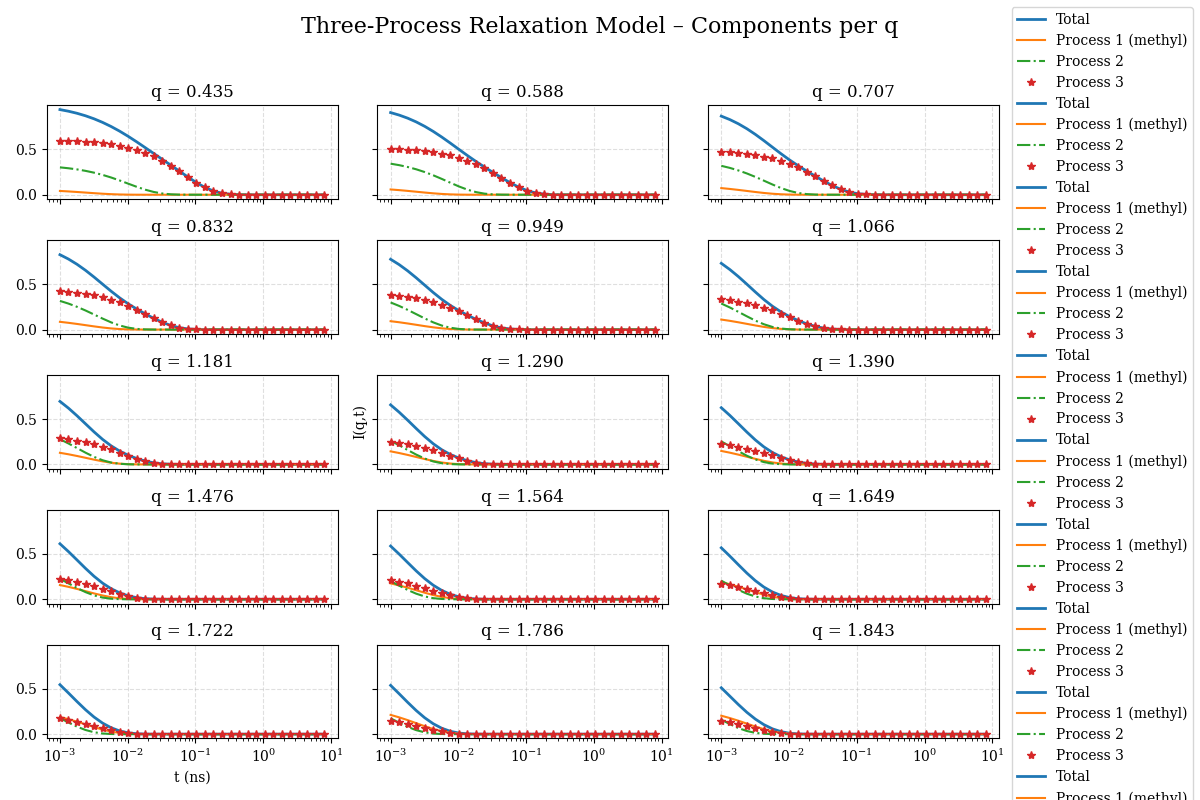

In [9]:
#components
#this file is in 1G9P_dielectric jupyterlab file 
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Constants
# =========================================================
hbar = 0.658211956      # eV·ps   (ħ = 0.658 eV⋅ps)
kB   = 1.0              #  kB = 1 (activation energies in K)

# =========================================================
# Q values (15)
# =========================================================
q_values = np.array([
    0.43540808, 0.58845368, 0.70713226, 0.83165897, 0.9486249,
    1.06619779, 1.18122469, 1.28966272, 1.38967442, 1.47556498,
    1.56379159, 1.64856688, 1.72216983, 1.78631603, 1.84264577
])

# =========================================================
# Amplitudes A0, A1, A2
# =========================================================
list_A0 = np.array([0.0009657886977749161, 0.0014876553811928586, 0.001681487429842621,
                    0.0019792513535979105, 0.001840671330765112, 0.001969653851920215,
                    0.0021634848120550636, 0.0023404931418369145, 0.002344894486172118,
                    0.002184628734619457, 0.0026856699619722023, 0.0024056426947987497,
                    0.0023066060219222263, 0.00288695901694066, 0.0032022878786680123])

list_A1 = np.array([0.005140566217599696, 0.006740176746551849, 0.0061053504367757855,
                    0.0065498977747983555, 0.005949824669927077, 0.005559624920647851,
                    0.0054204652931431, 0.005339752636322553, 0.005390546051116897,
                    0.0044799293680086415, 0.004773430927034098, 0.0041366053819079755,
                    0.0038434254113032976, 0.004278579350442772, 0.005071635883644618])

list_A2 = np.array([0.009321381907810494, 0.008818808910741752, 0.0075519853944502734,
                    0.006892619798367967, 0.005461882771146895, 0.00434827242080209,
                    0.0036595749366936446, 0.0031416015650911123, 0.002776972519776914,
                    0.002602594917132637, 0.002749997968794332, 0.0019112822293335802,
                    0.0019917293587952984, 0.0019060429580745296, 0.0022302303679973385])

# Normalize amplitudes per q
A = np.vstack([list_A0, list_A1, list_A2])
A = A / A.sum(axis=0)



Gamma0_1 = 7.380490922810943  

Gamma0_2 = np.array([
    20.639473063133295, 30.08398781637467, 46.359245701833345, 61.59534206009486, 
    85.0370456856586, 102.07683363847075, 115.16040846271106, 132.88394379656606, 
    146.93560139167025, 158.86500146216426, 177.43154064818978, 181.71183707698333, 
    204.3658173406241, 207.62660966839994, 231.11498782906622
])    # eV

Gamma0_3 = np.array([
    7.850564134353516, 12.60810284813038, 19.561620037081457, 28.44587695189194,
    38.269807145436324, 51.76111175930305, 64.21211100856361, 78.10908295067264, 
    91.81125004489408, 110.69349194018784, 130.65635929103306, 145.40979515915328, 
    169.76666874271876, 178.89037647757257, 193.70727679173183
])   # eV

Gamma0 = np.vstack([
    np.full(15, Gamma0_1),
    Gamma0_2,
    Gamma0_3
])


# =========================================================
# Activation energies (K)
# =========================================================
E = np.array([997.02, 1728.93, 2011.97])
# E = np.array([1252.62196121046, 2283.194211479879, 2712.6415741305937])



# =========================================================
# Relaxation time τ(q,T)
# =========================================================
def tau_qT(Gamma0_q, Ea, T):
    Gamma_T = Gamma0_q * np.exp(-Ea / T)
    return hbar / Gamma_T


# =========================================================
# I(q,t,T)
# =========================================================
def I_qt(q_index, t, T):
    A_q = A[:, q_index]
    G_q = Gamma0[:, q_index]

    tau = np.array([
        tau_qT(G_q[0], E[0], T),
        tau_qT(G_q[1], E[1], T),
        tau_qT(G_q[2], E[2], T),
    ])

    C1 = A_q[0] * np.exp(-t / tau[0])
    C2 = A_q[1] * np.exp(-t / tau[1])
    C3 = A_q[2] * np.exp(-t / tau[2])

    return C1 + C2 + C3, C1, C2, C3


T_plot = 300.0  # K

# t = np.linspace(1, 8000, 600)
t = np.logspace(0, np.log10(8000), 32)
t_ns = t 

fig, axes = plt.subplots(5, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
out_folder = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/252_6_02_679/reverse_eng/"
results_matrix = [t/1000] 
headers = ["time_ns"]

for i, ax in enumerate(axes):
    q = q_values[i]
    Itot, C1, C2, C3 = I_qt(i, t, T_plot)

    ax.plot(t_ns/1000, Itot, label="Total", lw=2)
    ax.plot(t_ns/1000, C1, "-",label="Process 1 (methyl)")
    ax.plot(t_ns/1000, C2, "-.", label="Process 2")
    ax.plot(t_ns/1000, C3, "*", label="Process 3")

    ax.set_title(f"q = {q:.3f}")
    ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    results_matrix.append(Itot)
    headers.append(f"Q_{q:.3f}")


final_data = np.column_stack(results_matrix)
print(final_data)
save_path = os.path.join(out_folder, f"I_qt_T_{T_plot}K_0kbar.txt")
np.savetxt(save_path, final_data, header="\t".join(headers), comments='', fmt='%.6e')
axes[12].set_xlabel("t (ns)")
axes[7].set_ylabel("I(q,t)")


fig.legend(loc="upper right", fontsize=10)
fig.suptitle("Three-Process Relaxation Model – Components per q", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()




[[1.00000000e-003 9.82740100e-001 9.74038603e-001 9.64212530e-001
  9.54101539e-001 9.41967562e-001 9.29160399e-001 9.18232509e-001
  9.06093678e-001 8.97071102e-001 8.92637499e-001 8.82809800e-001
  8.75146752e-001 8.68234219e-001 8.62262094e-001 8.53855673e-001]
 [1.33630665e-003 9.77360759e-001 9.65926497e-001 9.53019496e-001
  9.39748535e-001 9.23855372e-001 9.07163899e-001 8.92960849e-001
  8.77236582e-001 8.65569077e-001 8.59893525e-001 8.47296082e-001
  8.37400123e-001 8.28656767e-001 8.20979483e-001 8.10401779e-001]
 [1.78571545e-003 9.70473730e-001 9.55526446e-001 9.38664655e-001
  9.21346471e-001 9.00666296e-001 8.79089213e-001 8.60796018e-001
  8.40634352e-001 8.25708338e-001 8.18545146e-001 8.02616324e-001
  7.89977943e-001 7.79118979e-001 7.69373252e-001 7.56326648e-001]
 [2.38626343e-003 9.61768070e-001 9.42357525e-001 9.20483781e-001
  8.98053539e-001 8.71377626e-001 8.43781966e-001 8.20499483e-001
  7.94993702e-001 7.76168198e-001 7.67294802e-001 7.47512034e-001
  7.316

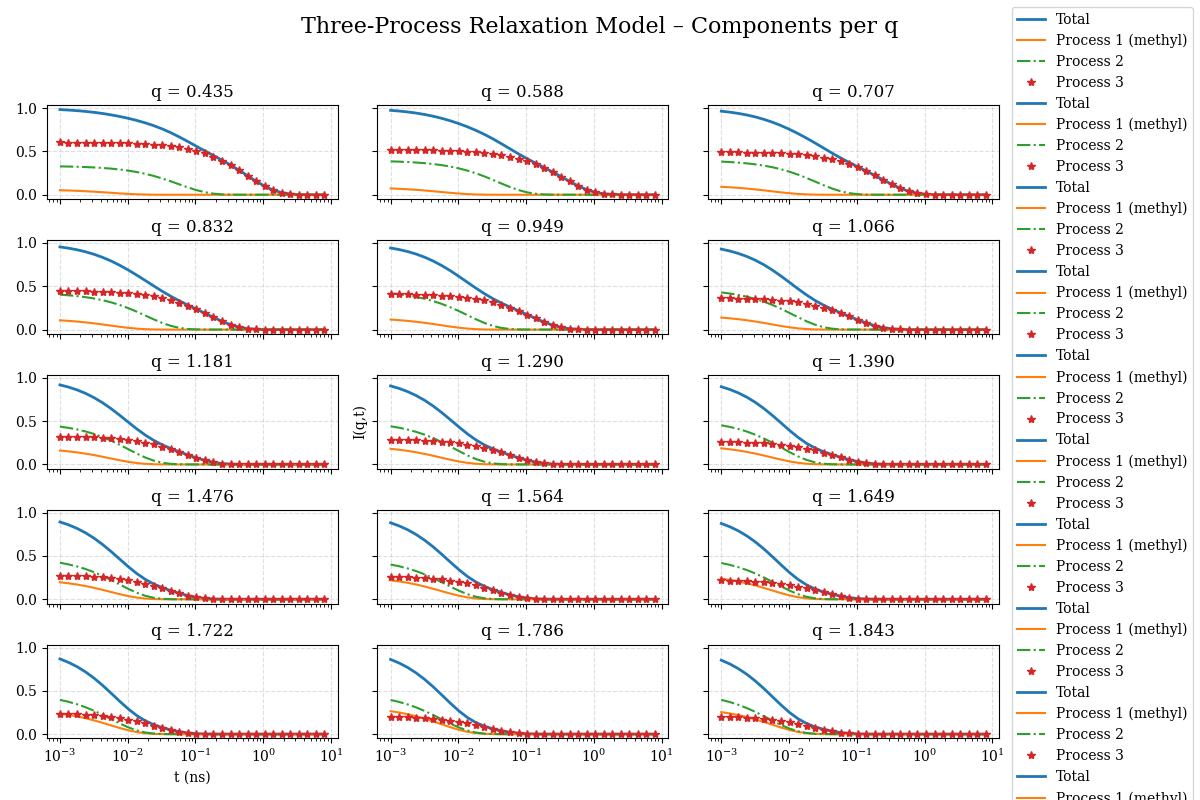

In [10]:
#components
#this file is in 1G9P_dielectric jupyterlab file 
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Constants
# =========================================================
hbar = 0.658211956      # eV·ps   (ħ = 0.658 eV⋅ps)
kB   = 1.0              #  kB = 1 (activation energies in K)

# =========================================================
# Q values (15)
# =========================================================
q_values = np.array([
    0.43540808, 0.58845368, 0.70713226, 0.83165897, 0.9486249,
    1.06619779, 1.18122469, 1.28966272, 1.38967442, 1.47556498,
    1.56379159, 1.64856688, 1.72216983, 1.78631603, 1.84264577
])

# =========================================================
# Amplitudes A0, A1, A2
# =========================================================
list_A0 = np.array([0.0009657886977749161, 0.0014876553811928586, 0.001681487429842621,
                    0.0019792513535979105, 0.001840671330765112, 0.001969653851920215,
                    0.0021634848120550636, 0.0023404931418369145, 0.002344894486172118,
                    0.002184628734619457, 0.0026856699619722023, 0.0024056426947987497,
                    0.0023066060219222263, 0.00288695901694066, 0.0032022878786680123])

list_A1 = np.array([0.005140566217599696, 0.006740176746551849, 0.0061053504367757855,
                    0.0065498977747983555, 0.005949824669927077, 0.005559624920647851,
                    0.0054204652931431, 0.005339752636322553, 0.005390546051116897,
                    0.0044799293680086415, 0.004773430927034098, 0.0041366053819079755,
                    0.0038434254113032976, 0.004278579350442772, 0.005071635883644618])

list_A2 = np.array([0.009321381907810494, 0.008818808910741752, 0.0075519853944502734,
                    0.006892619798367967, 0.005461882771146895, 0.00434827242080209,
                    0.0036595749366936446, 0.0031416015650911123, 0.002776972519776914,
                    0.002602594917132637, 0.002749997968794332, 0.0019112822293335802,
                    0.0019917293587952984, 0.0019060429580745296, 0.0022302303679973385])


A = np.vstack([list_A0, list_A1, list_A2])
A = A / A.sum(axis=0)



Gamma0_1 = 7.380490922810943  

Gamma0_2 = np.array([
    20.639473063133295, 30.08398781637467, 46.359245701833345, 61.59534206009486, 
    85.0370456856586, 102.07683363847075, 115.16040846271106, 132.88394379656606, 
    146.93560139167025, 158.86500146216426, 177.43154064818978, 181.71183707698333, 
    204.3658173406241, 207.62660966839994, 231.11498782906622
])    # eV

Gamma0_3 = np.array([
    7.850564134353516, 12.60810284813038, 19.561620037081457, 28.44587695189194,
    38.269807145436324, 51.76111175930305, 64.21211100856361, 78.10908295067264, 
    91.81125004489408, 110.69349194018784, 130.65635929103306, 145.40979515915328, 
    169.76666874271876, 178.89037647757257, 193.70727679173183
])   # eV

Gamma0 = np.vstack([
    np.full(15, Gamma0_1),
    Gamma0_2,
    Gamma0_3
])


# =========================================================
# Activation energies (K)
# =========================================================
# E = np.array([997.02, 1728.93, 2011.97])
# E = np.array([1252.62196121046, 2283.194211479879, 2712.6415741305937])

E = np.array([1237.5061062476354,2244.0019776070744, 2652.940943732253])




# =========================================================
# Relaxation time τ(q,T)
# =========================================================
def tau_qT(Gamma0_q, Ea, T):
    Gamma_T = Gamma0_q * np.exp(-Ea / T)
    return hbar / Gamma_T


# =========================================================
# I(q,t,T)
# =========================================================
def I_qt(q_index, t, T):
    A_q = A[:, q_index]
    G_q = Gamma0[:, q_index]

    tau = np.array([
        tau_qT(G_q[0], E[0], T),
        tau_qT(G_q[1], E[1], T),
        tau_qT(G_q[2], E[2], T),
    ])

    C1 = A_q[0] * np.exp(-t / tau[0])
    C2 = A_q[1] * np.exp(-t / tau[1])
    C3 = A_q[2] * np.exp(-t / tau[2])

    return C1 + C2 + C3, C1, C2, C3


T_plot = 300.0  # K

# t = np.linspace(1, 8000, 600)
t = np.logspace(0, np.log10(8000), 32)
t_ns = t 

fig, axes = plt.subplots(5, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
out_folder = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/252_6_02_679/reverse_eng/"
results_matrix = [t/1000] 
headers = ["time_ns"]

for i, ax in enumerate(axes):
    q = q_values[i]
    Itot, C1, C2, C3 = I_qt(i, t, T_plot)

    ax.plot(t_ns/1000, Itot, label="Total", lw=2)
    ax.plot(t_ns/1000, C1, "-",label="Process 1 (methyl)")
    ax.plot(t_ns/1000, C2, "-.", label="Process 2")
    ax.plot(t_ns/1000, C3, "*", label="Process 3")

    ax.set_title(f"q = {q:.3f}")
    ax.set_xscale("log")
    ax.grid(True, ls="--", alpha=0.4)
    results_matrix.append(Itot)
    headers.append(f"Q_{q:.3f}")


final_data = np.column_stack(results_matrix)
print(final_data)
save_path = os.path.join(out_folder, f"I_qt_T_{T_plot}K_5kbar.txt")
np.savetxt(save_path, final_data, header="\t".join(headers), comments='', fmt='%.6e')
axes[12].set_xlabel("t (ns)")
axes[7].set_ylabel("I(q,t)")

# Only one legend (outside)
fig.legend(loc="upper right", fontsize=10)
fig.suptitle("Three-Process Relaxation Model – Components per q", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.85, 0.96])
plt.show()


